# ✈️ Airport Cargo Loading Optimization
## Mathematical Formulations, Exact Methods, and Metaheuristics

---

##  Introduction

### Problem Overview

The **Airport Cargo Loading Problem** is a real-world combinatorial optimization challenge faced daily by airlines and freight operators. Given a set of heterogeneous cargo items — each with specific dimensions, weight, priority, and special handling requirements — the goal is to decide **which aircraft compartment each item should be loaded into**, minimizing total handling cost while satisfying a rich set of operational constraints.

This is not a trivial packing problem. Beyond the standard three-dimensional bin-packing geometry, aircraft cargo loading must simultaneously satisfy:

- **Weight capacity** per compartment (structural limits)
- **Volume capacity** per compartment (geometric limits)
- **Center-of-mass (CoM) balance** — both longitudinal and lateral — for flight safety
- **Incompatibility rules** — hazardous or chemically reactive items cannot share a bin
- **Co-location requirements** — items belonging to the same shipment must stay together
- **Structural constraints** — heavy items restricted to lower-deck compartments

Violating any of these constraints can ground an aircraft or create safety incidents, making feasibility as important as optimality.

### Why This Problem is Hard

The problem is **NP-complete** (proved in Section 4 by reduction from 3D-BPP). This means:
- No known polynomial-time algorithm exists for finding the optimal solution
- For $n = 50$ items and $m = 2$ bins, the search space has $2^{50} \approx 10^{15}$ candidate assignments
- Exact methods become impractical as $n$ grows beyond ~100 items

This motivates the use of both **exact solvers** (for small instances) and **metaheuristics** (for larger, real-time scenarios).

### What This Notebook Does

This notebook presents a complete computational study of the Airport Cargo Loading Problem:

| Section | Content |
|---|---|
| **1 · Setup** | Libraries, data loading, instance summary |
| **2 · MILP Formulation** | Mathematical model (binary IP), cost function, constraints C1–C9 |
| **3 · CP Formulation** | Graph-based conflict model, domain propagation |
| **4 · Complexity** | NP-hardness proof, implications for algorithm design |
| **5 · Branch & Bound** | Exact tree search with admissible lower bound |
| **6 · Solution Engine** | Encoding, neighbourhood operators, 6-pass repair heuristic |
| **7 · Genetic Algorithm** | Population-based metaheuristic with adaptive crossover |
| **8 · Simulated Annealing** | Local search with calibrated temperature and reheating |
| **9 · Experiments** | 13 benchmark instances, 4 methods, fixed seeds |
| **10 · Results** | Comparative charts, statistical summary, MILP vs metaheuristic gap |
| **11 · Conclusions** | Findings, recommendations, limitations |

### Why GA and SA Were Chosen

Two metaheuristics were selected to represent **complementary paradigms**:

**Genetic Algorithm (GA)** — a *population-based* method that maintains diversity through evolutionary operators. It is well-suited to this problem because:
- The integer encoding maps directly to bin assignments
- Crossover naturally combines good partial solutions from different parents
- Population diversity prevents early convergence on heavily constrained instances

**Simulated Annealing (SA)** — a *single-solution local search* method that uses a probabilistic acceptance criterion to escape local optima. It was chosen because:
- It is highly memory-efficient and fast per iteration
- Its violation-aware neighbourhood directly targets active constraint violations
- The auto-calibrated initial temperature ensures meaningful acceptance rates regardless of instance scale
- Reheating provides multiple opportunities to escape local optima within the time budget

Together, GA and SA bracket the performance landscape: GA explores broadly, SA exploits deeply.

---

**Structure**:
1. Setup & Data Loading  
2. Formulation 1 — Classical MILP  
3. Formulation 2 — Graph-Based CP Model  
4. Complexity Analysis  
5. Exact Method — Branch and Bound  
6. Solution Engine & Problem-Specific Operators  
7. Population-Based Metaheuristic — Genetic Algorithm  
8. Local Search Metaheuristic — Simulated Annealing  
9. Experiments (13 instances)  
10. Results & Comparative Analysis  
11. Conclusions


## 1 · Setup

### What this section does

This section installs and imports all required libraries, configures the working directories, and loads the benchmark instances from disk. Running it first is mandatory — all subsequent sections depend on the variables and classes defined here.

**Key configuration decisions:**
- `TIME_LIMIT_PER_RUN = 30` seconds — balances solution quality against total runtime (13 instances × 4 methods × 30 s = ~26 minutes maximum)
- `INSTANCES` includes 12 standard 3D-BPP benchmarks plus one custom test instance
- Matplotlib style is pre-configured for consistent, readable charts throughout


In [1]:
# Install PuLP from inside Jupyter Notebook

import sys
!{sys.executable} -m pip install pulp

### Code: Import Libraries and Configure Environment

The cell below imports scientific Python libraries (`numpy`, `pandas`, `matplotlib`), the `pulp` integer programming solver, and standard Python utilities. It then locates the input data directory and creates a results folder for saving experiment outputs.


In [2]:
import os, math, re, random, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Optional, Set, Dict
import matplotlib.cm as cm

warnings.filterwarnings('ignore')

try:
    import pulp
    _PULP = True
except ImportError:
    _PULP = False
    print('pulp not found — MILP and B&B will be skipped')

_NB = Path.cwd()

INPUT_DIR = None

for base_dir in [_NB / 'Input', _NB / 'input']:
    if base_dir.exists():
        txt_files = list(base_dir.rglob('3dBPP_*.txt'))
        if txt_files:
            INPUT_DIR = txt_files[0].parent
            break

if INPUT_DIR is None:
    raise FileNotFoundError(
        "Could not find any files matching '3dBPP_*.txt'"
    )

RESULTS_DIR = _NB / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'font.size': 11
})

TIME_LIMIT_PER_RUN = 30

INSTANCES = [f'3dBPP_{i}' for i in range(1, 13)] + ['3dBPP_test']

POP_COL = '#1565C0'
LS_COL = '#C62828'

ALL_METHODS = ['MILP', 'BnB', 'GA', 'SA']

METHOD_COLOR = {
    'MILP': '#37474F',
    'BnB': '#546E7A',
    'GA': POP_COL,
    'SA': LS_COL
}

print(f'Notebook dir : {_NB}')
print(f'Input dir    : {INPUT_DIR}')
print(f'txt files    : {len(list(INPUT_DIR.glob("3dBPP_*.txt")))}')
print(f'Results dir  : {RESULTS_DIR}')
print(f'Time/run     : {TIME_LIMIT_PER_RUN} s')
print('Setup done.')

Notebook dir : c:\Users\Admin\Documents\ensia\semester6\NMO\Project
Input dir    : c:\Users\Admin\Documents\ensia\semester6\NMO\Project\Input
txt files    : 13
Results dir  : c:\Users\Admin\Documents\ensia\semester6\NMO\Project\results
Time/run     : 30 s
Setup done.


###  Output Interpretation — Instance Summary Table

The table printed above summarises the 13 benchmark instances used throughout this study:

- **n** — number of cargo items after expanding quantities (e.g., "3 units of item type A" becomes 3 separate items)
- **m** — number of aircraft compartments (bins) available; most instances use 1–2 bins
- **Wt_cap** — weight capacity of the first compartment in kg; `—` means no weight constraint is active
- **Incompat** — number of incompatible item pairs (items that cannot share a bin)
- **CoLoc** — number of co-location pairs (items that must be in the same bin)

**What to look for:** Instances with `Incompat > 0` or `CoLoc > 0` are structurally harder — the solver must navigate conflicting assignment requirements simultaneously. Instances with `Wt_cap > 0` add a tighter feasibility envelope that the repair heuristic must satisfy.


## 2 · Formulation 1 — Classical MILP

### 2.1 Problem Data & Decision Variables

We model the problem as a **Binary Integer Programme**. Let:

- $I = \{0,\dots,n-1\}$ — set of cargo items (after expanding quantities)  
- $J = \{0,\dots,m-1\}$ — set of aircraft compartments (bins)  
- $x_{ij} \in \{0,1\}$ — 1 if item $i$ is assigned to compartment $j$  
- $y_j \in \{0,1\}$ — 1 if compartment $j$ is used  

### 2.2 Cost Function

The loading door is at the fuselage entrance $(x_d=0, y_d=750)$.  
Forward compartments are cheap; rear compartments are expensive:

$$c_{ij} = 1 + 50\,\frac{\|\text{pos}_j - \text{door}\|}{L} + 0.05\,w_i + 10\,(p_i-1)\,\frac{\|\text{pos}_j - \text{door}\|}{L}$$

where $L=1500$ is the fuselage length, $w_i$ the item weight, and $p_i$ the priority.

### 2.3 MILP Model

$$\min \sum_{i \in I}\sum_{j \in J} c_{ij}\,x_{ij} + \mu\sum_{j \in J} y_j$$

Subject to:

| # | Constraint | Description |
|---|---|---|
| C1 | $\sum_j x_{ij} = 1 \;\forall i$ | Every item assigned exactly once |
| C2 | $\sum_i w_i\,x_{ij} \le W_j \;\forall j$ | Weight capacity |
| C3 | $\sum_i v_i\,x_{ij} \le V_j \;\forall j$ | Volume capacity |
| C4 | $x_{ij}=0$ for heavy $i$, upper $j$ | Structural safety |
| C5 | $x_{ij}+x_{kj}\le 1 \;\forall (i,k)\in\mathcal{I}, j$ | Incompatibility |
| C6 | $x_{ij}=x_{kj} \;\forall (i,k)\in\mathcal{C}, j$ | Co-location |
| C7 | $\left|\bar{x}_{CoM} - x^*\right| \le \delta_x$ | Longitudinal balance |
| C8 | $\left|\bar{y}_{CoM} - y^*\right| \le \delta_y$ | Lateral balance |
| C9 | $x_{ij}\le y_j$; $y_j\ge y_{j+1}$ | Bin-usage + symmetry breaking |


### Code: Data Classes and Instance Loader

The following cell defines the core data structures (`CargoItem`, `Compartment`, `Instance`) and the `load_instance` / `load_all_instances` functions that parse the benchmark text files.

**Key design decisions:**
- **`Instance._build_cost()`** pre-computes the full $n \times m$ cost matrix at load time, avoiding repeated distance calculations during search
- **Loading door position** is fixed at $(x=0, y=750)$ — the fuselage nose entrance — making forward compartments (low x) cheaper than rear ones (high x). This asymmetry is what gives optimisation algorithms something to improve
- **`_assign_positions()`** spaces compartments linearly from $x=200$ to $x=1400$, alternating left/right laterally for CoM symmetry


In [3]:
@dataclass
class CargoItem:
    id:int; length:float; width:float; height:float; weight:float
    priority:int=2; fragile:bool=False
    @property
    def volume(self): return self.length*self.width*self.height

@dataclass
class Compartment:
    id:int; name:str; length:float; width:float; height:float
    weight_capacity:float
    pos_x:float=400.; pos_y:float=750.; is_lower:bool=True
    @property
    def volume_capacity(self): return self.length*self.width*self.height

class Instance:
    DOOR_X = 0.
    DOOR_Y = 750.
    MAX_DIST = 1500.

    def __init__(self, name, items, compartments,
                 heavy_items=None, incompatible_pairs=None, colocation_pairs=None,
                 target_com_x=750., target_com_y=750.,
                 com_tolerance_x=150., com_tolerance_y=200.):
        self.name = name
        self.items = items
        self.compartments = compartments
        self.heavy_items        = heavy_items        or set()
        self.incompatible_pairs = incompatible_pairs or []
        self.colocation_pairs   = colocation_pairs   or []
        self.target_com_x  = target_com_x
        self.target_com_y  = target_com_y
        self.com_tolerance_x = com_tolerance_x
        self.com_tolerance_y = com_tolerance_y
        self._build_cost()

    def _build_cost(self):
        n, m = self.n_items, self.n_compartments
        self.cost = np.zeros((n, m))
        for i, item in enumerate(self.items):
            for j, comp in enumerate(self.compartments):
                d  = math.hypot(comp.pos_x - self.DOOR_X, comp.pos_y - self.DOOR_Y)
                dn = d / self.MAX_DIST
                rho = item.volume / max(comp.volume_capacity, 1e-9)
                self.cost[i, j] = (
                    1.0 + 50.0*dn + 0.05*item.weight
                    + 10.0*(item.priority-1)*dn
                    + (8.0 if item.fragile else 0.0)
                    + 5.0*(1.0 - min(rho, 1.0))
                )

    @property
    def n_items(self):        return len(self.items)
    @property
    def n_compartments(self): return len(self.compartments)
    def lower_compartment_ids(self): return [c.id for c in self.compartments if c.is_lower]
    def total_item_weight(self): return sum(it.weight for it in self.items)
    def total_item_volume(self): return sum(it.volume for it in self.items)
    def __repr__(self):
        return f'Instance({self.name}, n={self.n_items}, m={self.n_compartments})'


def _assign_positions(comps):
    n = len(comps)
    xs = np.linspace(200, 1400, max(n, 1)).tolist()
    ys = [400., 1100.]
    for k, comp in enumerate(comps):
        comp.pos_x   = xs[k]
        comp.pos_y   = ys[k % 2]
        comp.is_lower = True

def load_instance(src) -> 'Instance':
    if isinstance(src, int): src = f'3dBPP_{src}'
    p = Path(str(src))
    if not p.suffix: p = INPUT_DIR / f'{p.name}.txt'
    if not p.exists(): raise FileNotFoundError(p)

    meta = {}; rows = []; started = False
    with open(p, encoding='utf-8') as fh:
        for raw in fh:
            ln = raw.strip()
            if not ln: continue
            if ln.startswith('#'):
                cl = ln.lstrip('#').strip()
                if ':' in cl:
                    k, v = cl.split(':', 1)
                    meta[k.strip().lower()] = v.strip()
                continue
            if re.search(r'-{4,}', ln): started = True; continue
            if 'id' in ln.lower() and 'quantity' in ln.lower(): continue
            if started:
                pts = re.split(r'\s+', ln)
                if len(pts) >= 6:
                    try: rows.append(tuple(int(x) for x in pts[:6]))
                    except ValueError: pass

    dm = re.search(r'(\d+)[^\d]+(\d+)[^\d]+(\d+)',
                   meta.get('bin dimensions (l * w * h)', ''))
    bl, bw, bh = (int(x) for x in dm.groups()) if dm else (1200, 1200, 1200)

    mw = meta.get('max weight', '').strip()
    wt_cap = float(mw) if re.match(r'^\d', mw) else 0.

    nb_m = re.search(r'\d+',
           meta.get('max num of bins', meta.get('max num of bins ', '1')))
    n_bins = int(nb_m.group()) if nb_m else 1

    cm_m = re.search(r'(\d+)[^\d]+(\d+)', meta.get('center of mass', ''))
    com_x, com_y = (float(cm_m.group(1)), float(cm_m.group(2))) if cm_m else (750., 750.)

    incompat = [(int(a), int(b)) for a, b in
                re.findall(r'\((\d+),\s*(\d+)\)', meta.get('incompatibilities', ''))]
    coloc    = [(int(a), int(b)) for a, b in
                re.findall(r'\((\d+),\s*(\d+)\)',
                meta.get('positive affinities', meta.get('positive affinity', '')))]

    comps = [Compartment(id=k, name=f'BIN_{k}',
                         length=float(bl), width=float(bw), height=float(bh),
                         weight_capacity=wt_cap)
             for k in range(n_bins)]
    _assign_positions(comps)

    items = []; tf = {}; uid = 0
    for (tid, qty, l, w, h, wt) in rows:
        if tid not in tf: tf[tid] = uid
        for _ in range(qty):
            items.append(CargoItem(id=uid, length=float(l), width=float(w),
                                   height=float(h), weight=float(wt)))
            uid += 1

    def _ep(a, b):
        return (tf[a], tf[b]) if a in tf and b in tf else None
    ie = [x for x in (_ep(a,b) for a,b in incompat) if x]
    ce = [x for x in (_ep(a,b) for a,b in coloc)    if x]

    tx = 120. if com_x != 750. else 150.
    ty = 150. if com_y != 750. else 200.
    return Instance(name=p.stem, items=items, compartments=comps,
                    incompatible_pairs=ie, colocation_pairs=ce,
                    target_com_x=com_x, target_com_y=com_y,
                    com_tolerance_x=tx, com_tolerance_y=ty)

def load_all_instances(src=None):
    src = src or INPUT_DIR
    files = sorted(src.glob('3dBPP_*.txt'),
                   key=lambda p: (int(m.group(1))
                                  if (m := re.search(r'(\d+)', p.stem)) else 9999))
    if not files: raise FileNotFoundError(f'No 3dBPP_*.txt in {src}')
    return [load_instance(f) for f in files]

instances = load_all_instances()
rows_s = [{'Instance': i.name, 'n': i.n_items, 'm': i.n_compartments,
           'Wt_cap': i.compartments[0].weight_capacity or '—',
           'Incompat': len(i.incompatible_pairs), 'CoLoc': len(i.colocation_pairs)}
          for i in instances]
print(pd.DataFrame(rows_s).set_index('Instance').to_string())
print(f'\nLoaded {len(instances)} instances.')


             n  m  Wt_cap  Incompat  CoLoc
Instance                                  
3dBPP_1     51  1       —         0      0
3dBPP_10    51  1       —         0      0
3dBPP_11    38  2   800.0         1      2
3dBPP_12    38  2   900.0         1      1
3dBPP_2     51  2  1000.0         0      0
3dBPP_3     52  1       —         0      0
3dBPP_4     52  1       —         0      0
3dBPP_5     53  1       —         0      0
3dBPP_6     53  2       —         2      0
3dBPP_7     46  1       —         0      0
3dBPP_8     46  2       —         1      2
3dBPP_9     47  1       —         0      0
3dBPP_test  38  2  1000.0         3      2

Loaded 13 instances.


###  Output Interpretation — Loaded Instances

The printed table confirms successful data loading. Check that:
- All 13 instances loaded without errors
- `n` ranges across a variety of problem sizes (the study uses instances from small to medium scale)
- The cost matrix is asymmetric: BIN_0 (near door, $x \approx 200$) should have lower average cost than BIN_1 (rear, $x \approx 1400$)

If any instance fails to load, verify the `Input/` directory contains all `3dBPP_*.txt` files.


### Code: MILP Solver

This cell implements the complete Mixed Integer Linear Programme using PuLP/CBC. All 9 constraints (C1–C9) are encoded as linear inequalities and equalities. The solver runs with a 60-second time limit and a 0.1% optimality gap tolerance.

**Notable implementation details:**
- The bin-usage penalty $\mu = 0.5$ encourages solutions that use fewer compartments
- Symmetry-breaking constraint C9 ($y_j \ge y_{j+1}$) eliminates duplicate solutions where bins are permuted, significantly reducing the branch-and-bound search tree
- CoM constraints (C7, C8) are linearised by multiplying through by the constant total weight $W_{\text{tot}}$


In [4]:
def solve_milp(instance, time_limit=120., verbose=False):
    if not _PULP:
        return dict(method='MILP', status='NO_SOLVER', feasible=False,
                    objective=float('inf'), solve_time=0., assignment=None, solution=None)
    t0 = time.perf_counter()
    inst = instance; n, m = inst.n_items, inst.n_compartments
    I, J = range(n), range(m)
    model = pulp.LpProblem(f'Cargo_{inst.name}', pulp.LpMinimize)
    x = [[pulp.LpVariable(f'x_{i}_{j}', cat='Binary') for j in J] for i in I]
    y = [pulp.LpVariable(f'y_{j}', cat='Binary') for j in J]
    MU = 0.5

    model += (pulp.lpSum(inst.cost[i,j]*x[i][j] for i in I for j in J)
              + MU*pulp.lpSum(y[j] for j in J), 'TotalCost')

    for i in I:
        model += pulp.lpSum(x[i][j] for j in J) == 1, f'C1_{i}'

    for j in J:
        cap = inst.compartments[j].weight_capacity
        if cap > 0:
            model += pulp.lpSum(inst.items[i].weight*x[i][j] for i in I) <= cap, f'C2_{j}'

    for j in J:
        vc = inst.compartments[j].volume_capacity
        model += pulp.lpSum(inst.items[i].volume*x[i][j] for i in I) <= vc, f'C3_{j}'

    lower = set(inst.lower_compartment_ids())
    upper = [j for j in J if j not in lower]
    for i in inst.heavy_items:
        for j in upper: model += x[i][j] == 0, f'C4_{i}_{j}'

    for idx,(a,b) in enumerate(inst.incompatible_pairs):
        for j in J: model += x[a][j]+x[b][j] <= 1, f'C5_{idx}_{j}'

    for idx,(a,b) in enumerate(inst.colocation_pairs):
        for j in J: model += x[a][j] == x[b][j], f'C6_{idx}_{j}'

    Wt = inst.total_item_weight()
    if Wt > 0:
        ex = pulp.lpSum(inst.items[i].weight*inst.compartments[j].pos_x
                        *x[i][j] for i in I for j in J)
        model += ex >= Wt*(inst.target_com_x - inst.com_tolerance_x), 'C7_lo'
        model += ex <= Wt*(inst.target_com_x + inst.com_tolerance_x), 'C7_hi'
        ey = pulp.lpSum(inst.items[i].weight*inst.compartments[j].pos_y
                        *x[i][j] for i in I for j in J)
        model += ey >= Wt*(inst.target_com_y - inst.com_tolerance_y), 'C8_lo'
        model += ey <= Wt*(inst.target_com_y + inst.com_tolerance_y), 'C8_hi'

    for i in I:
        for j in J: model += x[i][j] <= y[j], f'C9lnk_{i}_{j}'
    for j in range(m-1):
        model += y[j] >= y[j+1], f'C9sym_{j}'

    solver = pulp.PULP_CBC_CMD(timeLimit=int(time_limit), msg=1 if verbose else 0, gapRel=0.001)
    model.solve(solver)
    elapsed = time.perf_counter()-t0
    status  = pulp.LpStatus[model.status]
    ok      = model.status in (1, -2)

    assignment = None; sol_obj = None; solution = None
    if ok:
        assignment = [-1]*n
        for i in I:
            for j in J:
                v = pulp.value(x[i][j])
                if v is not None and v > 0.5: assignment[i]=j; break
        sol_obj = sum(inst.cost[i,assignment[i]] for i in I if assignment[i]>=0)
        solution = None  # filled after Solution class is defined

    return dict(method='MILP', status=status, feasible=ok,
                objective=sol_obj if ok else float('inf'),
                solve_time=elapsed, assignment=assignment, solution=solution)

print('MILP solver defined.')


MILP solver defined.


###  Output Interpretation — MILP Solver Definition

`MILP solver defined.` confirms the solver function was compiled without errors. The MILP is not yet run here — it will be called during the experiments in Section 9. At that point, for each instance you will see:
- **Optimal** — solver proved optimality within the gap tolerance
- **Time Limit** — solver hit 60 s and returned the best incumbent found
- **Infeasible** — no assignment satisfies all constraints simultaneously (rare with our repair pre-processing)

Instances with $m=1$ bin are typically solved in under 1 second. Instances with $m=2$ bins and tight CoM tolerances may require the full 60 seconds.


## 3 · Formulation 2 — Graph-Based / Constraint Programming Model

### 3.1 Alternative Modelling Perspective

Rather than treating the problem as a pure integer programme, we model it as a  
**graph colouring with weighted constraints** interpreted through Constraint Programming (CP).

**Key difference from MILP**: the MILP assigns continuous weight/volume penalties  
via linear inequalities. The CP model expresses the *same constraints* through  
domain propagation and explicit constraint objects — a fundamentally different  
abstraction layer that allows inference without solving an LP relaxation.

### 3.2 Graph Construction

Define a conflict graph $G = (V, E)$ where:
- **Nodes** $V = I$ (one per cargo item)  
- **Edges** $E$: connect items that *cannot share* a compartment:
  - Incompatible pairs $(i,k) \in \mathcal{I}$
  - Items that together would violate weight capacity in any single bin
  - Items that together would violate volume capacity in any single bin

### 3.3 CP Model

**Variables**: $x_i \in \{0,\dots,m-1\}$ — compartment assigned to item $i$

**Constraints**:

| Type | Expression | CP Propagator |
|---|---|---|
| Graph colouring | $x_i \ne x_k \quad \forall (i,k)\in E$ | `AllDifferentExcept` / `NotEqual` |
| Co-location | $x_i = x_k \quad \forall (i,k)\in \mathcal{C}$ | `Equal` |
| Weight bin | $\sum_{i:x_i=j} w_i \le W_j \quad \forall j$ | `BinPacking` |
| Volume bin | $\sum_{i:x_i=j} v_i \le V_j \quad \forall j$ | `BinPacking` |
| Heavy items | $x_i \in J_{\text{lower}} \quad \forall i\in H$ | Domain reduction |
| Balance | $\left\|\bar{x}_{CoM}(\mathbf{x}) - x^*\right\| \le \delta_x$ | Arithmetic + `Element` |

**Objective**: minimise $\sum_i c_{i,x_i}$ (element constraint on cost matrix)

### 3.4 Why This Is a Different Abstraction

| Dimension | MILP (Formulation 1) | CP Graph Model (Formulation 2) |
|---|---|---|
| Representation | Binary matrix $x_{ij}$ | Integer assignment $x_i$ |
| Incompatibility | Linear inequality per bin | Edge in conflict graph / `NotEqual` |
| Capacity | Weighted sum ≤ bound | `BinPacking` propagator |
| Solving paradigm | Branch-and-cut on LP relaxations | Constraint propagation + search |
| Strengths | Proven optimality gap bounds | Fast pruning via arc-consistency |

### 3.5 CP Model Implementation (using `python-constraint` / penalty relaxation)


### Code: Conflict Graph and CP Solver

This cell builds the conflict graph $G=(V,E)$ from the instance data and implements a constraint-propagation-inspired greedy solver. The three types of conflict edges capture incompatibility at different levels: explicit rules, weight overload, and volume overload.

**Key function roles:**
- **`build_conflict_graph`** — constructs edges representing all pairs of items that *cannot* share a compartment; used for the chromatic lower bound and for constraint propagation
- **`cp_chromatic_lower_bound`** — finds a maximum clique approximation; the clique size is a lower bound on the number of bins needed (items in a clique all conflict with each other)
- **`solve_cp_greedy`** — assigns items in most-constrained-first order, filtering domains by capacity and conflict constraints at each step; co-location constraints are propagated immediately when one partner is assigned


In [5]:
def build_conflict_graph(instance):
    """
    Build the conflict graph G=(V,E) for the CP formulation.
    Returns adjacency list: edges where items CANNOT share a bin.
    """
    inst = instance
    n, m = inst.n_items, inst.n_compartments
    edges = set()

    # Edge type 1: explicit incompatibility pairs
    for (i, k) in inst.incompatible_pairs:
        edges.add((min(i,k), max(i,k)))

    # Edge type 2: weight-infeasibility edges
    # If w_i + w_k > min weight capacity across all bins, they conflict in any single bin
    wt_caps = [c.weight_capacity for c in inst.compartments if c.weight_capacity > 0]
    if wt_caps:
        min_wt_cap = min(wt_caps)
        for i in range(n):
            for k in range(i+1, n):
                if inst.items[i].weight + inst.items[k].weight > min_wt_cap:
                    edges.add((i, k))

    # Edge type 3: volume-infeasibility edges (only if extremely large items)
    for j, comp in enumerate(inst.compartments):
        vc = comp.volume_capacity
        for i in range(n):
            for k in range(i+1, n):
                if inst.items[i].volume + inst.items[k].volume > vc:
                    edges.add((min(i,k), max(i,k)))

    return edges

def cp_chromatic_lower_bound(instance):
    """
    Compute a lower bound on the number of bins needed via graph clique analysis.
    A clique in the conflict graph = items that all must be in different bins.
    """
    edges = build_conflict_graph(instance)
    n = instance.n_items
    adj = [set() for _ in range(n)]
    for (i,k) in edges: adj[i].add(k); adj[k].add(i)
    # Greedy max-clique approximation
    best_clique = []
    for start in range(n):
        clique = [start]
        candidates = set(adj[start])
        while candidates:
            v = max(candidates, key=lambda x: len(adj[x] & candidates))
            clique.append(v)
            candidates &= adj[v]
        if len(clique) > len(best_clique):
            best_clique = clique
    return len(best_clique), best_clique

def solve_cp_greedy(instance, time_limit=60.):
    """
    CP-inspired solver: use constraint propagation logic to assign items.
    Enforces the graph colouring (conflict) constraints explicitly.
    Returns a Solution object.
    """
    t0 = time.perf_counter()
    inst = instance
    n, m = inst.n_items, inst.n_compartments
    lo = set(inst.lower_compartment_ids())

    # Domain of each variable: initially all bins
    domains = [list(lo) if i in inst.heavy_items else list(range(m))
               for i in range(n)]

    # Build conflict graph
    conflict_edges = build_conflict_graph(inst)
    adj = [set() for _ in range(n)]
    for (i,k) in conflict_edges: adj[i].add(k); adj[k].add(i)

    # Co-location: merge domains for co-located pairs
    coloc_map = {}
    for (i,k) in inst.colocation_pairs:
        dom = [j for j in domains[i] if j in domains[k]]
        domains[i] = dom; domains[k] = dom
        coloc_map[i] = k; coloc_map[k] = i

    assignment = [-1]*n
    cw = [0.]*m; cv_ = [0.]*m

    # Order: most-constrained first (smallest domain, then heaviest)
    order = sorted(range(n), key=lambda i: (len(domains[i]),
                                             -inst.items[i].weight))

    for i in order:
        if assignment[i] >= 0: continue
        item = inst.items[i]

        # Filter domain by capacity and conflict constraints
        valid = []
        for j in domains[i]:
            comp = inst.compartments[j]
            # Weight check
            if comp.weight_capacity>0 and cw[j]+item.weight > comp.weight_capacity:
                continue
            # Volume check
            if cv_[j]+item.volume > comp.volume_capacity:
                continue
            # Conflict (graph colouring) check
            conflict = False
            for k in adj[i]:
                if assignment[k] == j: conflict=True; break
            if conflict: continue
            valid.append(j)

        # Propagation: if domain wipes out, relax volume (soft) and pick least cost
        if not valid:
            valid = [j for j in domains[i]
                     if inst.compartments[j].weight_capacity==0
                     or cw[j]+item.weight <= inst.compartments[j].weight_capacity*1.2]
        if not valid:
            valid = domains[i] or list(range(m))

        # Select bin with minimum cost (objective element constraint)
        bc = min(valid, key=lambda j: inst.cost[i,j])
        assignment[i] = bc
        cw[bc]  += item.weight
        cv_[bc] += item.volume

        # Propagate co-location
        partner = coloc_map.get(i)
        if partner is not None and assignment[partner] < 0:
            # Force partner to same bin if feasible
            pi = inst.items[partner]
            wok = (inst.compartments[bc].weight_capacity==0 or
                   cw[bc]+pi.weight <= inst.compartments[bc].weight_capacity*1.1)
            vok = cv_[bc]+pi.volume <= inst.compartments[bc].volume_capacity*1.1
            if wok and vok:
                assignment[partner] = bc
                cw[bc]  += pi.weight
                cv_[bc] += pi.volume

        if time.perf_counter()-t0 > time_limit: break

    return assignment

# ── Demonstrate CP model on a sample instance ─────────────────────────────────
inst_demo = instances[10]  # 3dBPP_11: has incompatibilities, co-location, CoM
lb, clique = cp_chromatic_lower_bound(inst_demo)
edges = build_conflict_graph(inst_demo)
print(f'Instance: {inst_demo}')
print(f'  Conflict graph: {inst_demo.n_items} nodes, {len(edges)} edges')
print(f'  Chromatic lower bound (clique size): {lb} bins needed')
print(f'  Max clique items: {clique[:8]}...' if len(clique)>8 else f'  Max clique: {clique}')
print()
a = solve_cp_greedy(inst_demo)
print(f'  CP greedy assignment: {len(set(a))} distinct bins used')
for j in range(inst_demo.n_compartments):
    items_in_j = [i for i,x in enumerate(a) if x==j]
    wt = sum(inst_demo.items[i].weight for i in items_in_j)
    print(f'    BIN_{j}: {len(items_in_j)} items, weight={wt:.0f}')


Instance: Instance(3dBPP_8, n=46, m=2)
  Conflict graph: 46 nodes, 1 edges
  Chromatic lower bound (clique size): 2 bins needed
  Max clique: [21, 39]

  CP greedy assignment: 2 distinct bins used
    BIN_0: 45 items, weight=1172
    BIN_1: 1 items, weight=20


###  Output Interpretation — Conflict Graph Analysis

The output reports three key statistics for the demo instance (3dBPP_11):

- **Conflict graph edges** — the total number of item pairs that cannot share a bin. A high edge count relative to $n^2/2$ means the instance is heavily constrained and most bin assignments are forbidden
- **Chromatic lower bound** — the minimum number of bins that *must* be used (clique size). If this equals $m$, the problem is tight: every bin must be used and there is no slack in the assignment structure
- **CP greedy assignment** — shows how many distinct bins the propagation solver actually used. Ideally this equals or is close to the lower bound; a larger number indicates that the propagation solver could not pack as tightly as theoretically possible

**Items per bin and bin weights** tell you whether the CP solver distributed load evenly or created an imbalanced assignment that would need correction by the repair heuristic.


## 4 · Complexity Analysis

### 4.1 Decision Problem

The **Airport Cargo Loading Decision Problem (ACLDP)** asks:  
*"Given items $I$, bins $J$ with capacities, constraints C1–C9, and a threshold $K$, does a feasible assignment exist with cost $\le K$?"*

### 4.2 NP-Hardness Proof (Reduction from Bin Packing)

**Theorem**: ACLDP is **NP-hard**.

**Proof sketch** (polynomial reduction from 3-Dimensional Bin Packing, which is NP-hard):

1. Given a 3D-BPP instance with items $I$ and bins of capacity $C$, construct an ACLDP instance:
   - Set weight capacities equal to $C$
   - Set cost $c_{ij}=1$ for all $i,j$ (uniform)
   - Set $K = |I|$ (trivially feasible objective)
   - Disable all aircraft-specific constraints (no incompatibility, no CoM)
2. A feasible ACLDP solution with $\le B$ bins used exists iff the 3D-BPP instance can be packed into $B$ bins.
3. The reduction is polynomial: $O(n)$ in the number of items.

Therefore ACLDP is at least as hard as 3D-BPP. $\square$

### 4.3 NP-Membership

ACLDP $\in$ **NP**: given a certificate (the assignment vector $\mathbf{x}$), we can verify feasibility of all 9 constraints in $O(n \cdot m)$ time.

**Conclusion**: ACLDP is **NP-complete**.

### 4.4 Implications

| Method | Complexity | Guarantees |
|---|---|---|
| MILP (exact) | Exponential worst-case | Optimal (within gap) |
| Branch & Bound (exact) | Exponential worst-case | Optimal |
| Genetic Algorithm | $O(g \cdot p \cdot n)$ per run | No guarantee |
| Simulated Annealing | $O(t_{\max} \cdot n)$ per run | No guarantee |

For $n \approx 50$–$100$ items and $m \le 2$ bins (our instances), exact methods are feasible within minutes. For industrial-scale instances ($n > 500$), metaheuristics are essential.


### Interpretation — Complexity Analysis

This section establishes the theoretical difficulty of the problem. The key takeaway from the NP-completeness result is **practical**: it tells us that we should not expect any algorithm to reliably find proven-optimal solutions in polynomial time as instances grow larger.

**Implications for algorithm design:**

| Instance scale | Recommended approach | Reason |
|---|---|---|
| $n \le 60$, $m \le 2$ | MILP or B&B | Proven optimal within seconds |
| $60 < n \le 200$ | SA with reheating | Fast iterations, calibrated temperature |
| $n > 200$ | GA or hybrid | Population diversity avoids local optima |
| Real-time ($<$ 5 s) | Greedy + repair | Guarantees feasibility, no optimisation |

The NP-hardness proof via reduction from 3D-BPP also means that any improvement in 3D-BPP algorithms directly translates to better bounds here. For our benchmark instances ($n \le 100$, $m \le 2$), the problem remains tractable for exact methods with the symmetry-breaking constraint C9.


## 5 · Exact Method — Branch and Bound

### 5.1 Algorithm Description

Branch and Bound (B&B) enumerates the assignment tree systematically.  
At each node, it:
1. **Branches** on the next unassigned item, trying each feasible bin
2. **Bounds** using a lower bound (LP relaxation or greedy estimate)
3. **Prunes** subtrees where the lower bound exceeds the best known solution

### 5.2 Lower Bound

At a partial assignment where items $0,\dots,k-1$ are assigned:
$$LB = \sum_{i=0}^{k-1} c_{i,x_i} + \sum_{i=k}^{n-1} \min_j c_{ij}$$

This is admissible (never overestimates) because it assumes each remaining item  
can be placed in its globally cheapest compartment ignoring capacity.

### 5.3 Branching Strategy

- **Variable ordering**: most-constrained item first (fewest feasible bins)  
- **Value ordering**: cheapest bin first (for tighter pruning)
- **Feasibility check**: capacity, incompatibility, co-location at each node


### Code: Solution Class (Evaluation and Penalties)

Before implementing Branch and Bound, we need the `Solution` class, which is the evaluation backbone used by all four methods. It computes both the true objective value and a penalised cost that smoothly handles infeasible solutions.

**Penalty weight rationale:**
- `P_UNASSIGNED = 2000` is deliberately enormous — an unassigned item is always worse than any feasible assignment
- `P_INCOMPAT = 1200` and `P_COLOC = 900` are high because these are hard safety/operational constraints
- `P_BALANCE = 5` per cm of CoM drift is low because small deviations are sometimes unavoidable and the repair heuristic handles them iteratively

The `evaluate()` method uses a cache (`_cache`) so that an unchanged solution is not re-evaluated on every property access — critical for performance inside tight search loops.


In [6]:
class Solution:
    P_UNASSIGNED = 2000.; P_WEIGHT  = 20.;  P_VOLUME = 2e-4
    P_HEAVY      =  800.; P_INCOMPAT= 1200.; P_COLOC  = 900.; P_BALANCE = 5.

    def __init__(self, instance, assignment=None):
        self.instance   = instance
        self.assignment = (list(assignment) if assignment is not None
                           else [-1]*instance.n_items)
        self._cache = None

    def _dirty(self): self._cache = None
    def copy(self):   return Solution(self.instance, self.assignment[:])
    def assign(self, i, j): self.assignment[i] = j; self._dirty()

    def evaluate(self):
        if self._cache: return self._cache
        inst = self.instance; n, m = inst.n_items, inst.n_compartments
        a = self.assignment; vl = {}
        obj = sum(inst.cost[i,j] for i,j in enumerate(a) if j>=0)
        ua  = [i for i,j in enumerate(a) if j<0]
        if ua: vl['unassigned'] = ua
        cw = np.zeros(m); cv = np.zeros(m)
        for i,j in enumerate(a):
            if j>=0: cw[j]+=inst.items[i].weight; cv[j]+=inst.items[i].volume
        wv = [(j, cw[j]-inst.compartments[j].weight_capacity) for j in range(m)
              if inst.compartments[j].weight_capacity>0
              and cw[j]>inst.compartments[j].weight_capacity]
        if wv: vl['weight'] = wv
        vv = [(j, cv[j]-inst.compartments[j].volume_capacity) for j in range(m)
              if cv[j]>inst.compartments[j].volume_capacity]
        if vv: vl['volume'] = vv
        lo = set(inst.lower_compartment_ids())
        hv = [i for i in inst.heavy_items if a[i]>=0 and a[i] not in lo]
        if hv: vl['heavy'] = hv
        iv = [(p,q) for p,q in inst.incompatible_pairs if a[p]>=0 and a[p]==a[q]]
        if iv: vl['incompatible'] = iv
        cv2= [(p,q) for p,q in inst.colocation_pairs if a[p]!=a[q]]
        if cv2: vl['colocation'] = cv2
        tw = cw.sum()
        if tw>0:
            cx=sum(inst.items[i].weight*inst.compartments[j].pos_x
                   for i,j in enumerate(a) if j>=0)/tw
            cy=sum(inst.items[i].weight*inst.compartments[j].pos_y
                   for i,j in enumerate(a) if j>=0)/tw
            if abs(cx-inst.target_com_x)>inst.com_tolerance_x: vl['balance_x']=(cx,abs(cx-inst.target_com_x))
            if abs(cy-inst.target_com_y)>inst.com_tolerance_y: vl['balance_y']=(cy,abs(cy-inst.target_com_y))
        f = (len(vl)==0)
        self._cache = (obj,f,vl)
        return self._cache

    @property
    def penalized_cost(self):
        inst=self.instance; n,m=inst.n_items,inst.n_compartments; a=self.assignment
        o = sum(inst.cost[i,j] for i,j in enumerate(a) if j>=0)
        o += self.P_UNASSIGNED*sum(1 for j in a if j<0)
        cw=np.zeros(m); cv=np.zeros(m)
        for i,j in enumerate(a):
            if j>=0: cw[j]+=inst.items[i].weight; cv[j]+=inst.items[i].volume
        for j in range(m):
            ec=inst.compartments[j].weight_capacity; ev=inst.compartments[j].volume_capacity
            if ec>0 and cw[j]>ec: o+=(cw[j]-ec)*self.P_WEIGHT
            if ev>0 and cv[j]>ev: o+=(cv[j]-ev)*self.P_VOLUME
        lo=set(inst.lower_compartment_ids())
        o+=self.P_HEAVY*sum(1 for i in inst.heavy_items if a[i]>=0 and a[i] not in lo)
        o+=self.P_INCOMPAT*sum(1 for p,q in inst.incompatible_pairs if a[p]>=0 and a[p]==a[q])
        o+=self.P_COLOC*sum(1 for p,q in inst.colocation_pairs if a[p]!=a[q])
        tw=cw.sum()
        if tw>0:
            cx=sum(inst.items[i].weight*inst.compartments[j].pos_x
                   for i,j in enumerate(a) if j>=0)/tw
            cy=sum(inst.items[i].weight*inst.compartments[j].pos_y
                   for i,j in enumerate(a) if j>=0)/tw
            dx=abs(cx-inst.target_com_x)-inst.com_tolerance_x
            dy=abs(cy-inst.target_com_y)-inst.com_tolerance_y
            if dx>0: o+=dx*self.P_BALANCE
            if dy>0: o+=dy*self.P_BALANCE
        return o

    @property
    def objective(self):   c,_,_=self.evaluate(); return c
    @property
    def is_feasible(self): _,f,_=self.evaluate(); return f
    @property
    def violations(self):  _,_,v=self.evaluate(); return v

    def com(self):
        inst=self.instance; tw=sx=sy=0.
        for i,j in enumerate(self.assignment):
            if j>=0:
                w=inst.items[i].weight; tw+=w
                sx+=w*inst.compartments[j].pos_x; sy+=w*inst.compartments[j].pos_y
        return (sx/tw,sy/tw) if tw else (0.,0.)

    def __repr__(self):
        o,f,_=self.evaluate(); return f'Solution(obj={o:.2f}, feasible={f})'


print('Solution class defined.')


Solution class defined.


###  Output Interpretation — Solution Class

`Solution class defined.` confirms the evaluation machinery is ready. The Solution class will be used by every subsequent algorithm. The `penalized_cost` property is the primary signal used by all metaheuristics; the `objective` property is only meaningful when `is_feasible` is True.


### Code: Branch and Bound Solver

The B&B solver below implements systematic enumeration with:
- **Most-constrained-first branching**: items with fewer feasible bins are assigned first, which yields tighter pruning earlier in the tree
- **Admissible lower bound**: partial cost + minimum possible cost for all remaining items (ignoring capacity) — this is never an overestimate, so pruning is always correct
- **Explicit stack** (iterative DFS): avoids Python's recursion limit on deep trees


In [7]:
def solve_bnb(instance, time_limit=120., verbose=False):
    """
    Branch and Bound for the cargo loading problem.
    - Branching: item-by-item in most-constrained-first order
    - Lower bound: partial cost + sum of min-cost for remaining items
    - Pruning: LB >= best_known, or hard constraint violation detected early
    """
    t0 = time.perf_counter()
    inst = instance
    n, m = inst.n_items, inst.n_compartments
    lo   = set(inst.lower_compartment_ids())

    # Pre-compute min cost per item (for LB)
    min_cost = [min(inst.cost[i,j] for j in range(m)) for i in range(n)]
    suffix_min = [0.]*n  # suffix_min[k] = sum of min_cost[k..n-1]
    for k in range(n-2, -1, -1):
        suffix_min[k] = suffix_min[k+1] + min_cost[k+1]

    # Order items: most constrained first
    def _feasible_bins(i, assignment, cw, cv):
        bins = []
        for j in (list(lo) if i in inst.heavy_items else range(m)):
            comp = inst.compartments[j]
            if comp.weight_capacity>0 and cw[j]+inst.items[i].weight>comp.weight_capacity:
                continue
            if cv[j]+inst.items[i].volume > comp.volume_capacity:
                continue
            conflict = any(assignment[k]==j for k in inst.incompatible_pairs
                           if hasattr(inst.incompatible_pairs,'__iter__')
                           for _ in [None]
                           if False)  # simplified below
            bins.append(j)
        # Remove incompatible bins
        incompat_set = {}
        for (p,q) in inst.incompatible_pairs:
            incompat_set.setdefault(p,[]).append(q)
            incompat_set.setdefault(q,[]).append(p)
        partners = incompat_set.get(i, [])
        bins = [j for j in bins
                if not any(assignment[k]==j for k in partners if assignment[k]>=0)]
        return bins

    item_order = sorted(range(n),
        key=lambda i: len(lo) if i in inst.heavy_items else m)

    best_obj = float('inf')
    best_asgn = None
    nodes_explored = 0

    # Stack: (depth, assignment_list, partial_cost, cw_list, cv_list)
    init_a  = [-1]*n
    init_cw = [0.]*m
    init_cv = [0.]*m
    stack   = [(0, init_a, 0., init_cw, init_cv)]

    while stack:
        if time.perf_counter()-t0 > time_limit:
            break
        depth, assignment, partial_cost, cw, cv = stack.pop()
        nodes_explored += 1

        if depth == n:
            # Complete assignment — check feasibility
            sol = Solution(inst, assignment)
            if sol.is_feasible and partial_cost < best_obj:
                best_obj = partial_cost
                best_asgn = assignment[:]
                if verbose: print(f'  New best: {best_obj:.2f} (nodes={nodes_explored})')
            continue

        item_idx = item_order[depth]
        lb = partial_cost + suffix_min[item_idx]
        if lb >= best_obj:
            continue  # prune

        # Try each feasible bin for this item, cheapest first
        fb = _feasible_bins(item_idx, assignment, cw, cv)
        if not fb:
            fb = list(lo) if item_idx in inst.heavy_items else list(range(m))

        fb.sort(key=lambda j: inst.cost[item_idx, j])

        for j in reversed(fb):  # reversed so cheapest is popped first
            new_a  = assignment[:]
            new_a[item_idx] = j
            new_cost = partial_cost + inst.cost[item_idx, j]
            if new_cost + suffix_min[item_idx] >= best_obj:
                continue
            new_cw = cw[:]
            new_cv = cv[:]
            new_cw[j] += inst.items[item_idx].weight
            new_cv[j] += inst.items[item_idx].volume
            stack.append((depth+1, new_a, new_cost, new_cw, new_cv))

    elapsed = time.perf_counter()-t0
    feasible = best_asgn is not None
    sol = Solution(inst, best_asgn) if feasible else Solution(inst, [-1]*n)

    return dict(method='BnB', feasible=feasible,
                objective=best_obj if feasible else float('inf'),
                solve_time=elapsed, assignment=best_asgn,
                solution=sol, nodes=nodes_explored)

print('Branch and Bound solver defined.')


Branch and Bound solver defined.


###  Output Interpretation — Branch and Bound

`Branch and Bound solver defined.` confirms successful compilation. When B&B runs in the experiments (Section 9), the output will show:
- **nodes_explored** — how much of the search tree was visited before finding the optimal or hitting the time limit
- A small node count (< 1000) means the lower bound pruned the tree aggressively — the instance is easy for B&B
- A large node count (~millions) before time-out means the instance has many near-optimal partial assignments that are hard to prune — the instance is hard for B&B, and metaheuristics may be more practical

B&B is guaranteed to find the optimal solution if given enough time, but makes no guarantee when cut off early.


## 6 · Solution Engine & Problem-Specific Operators

### 6.1 Encoding

A solution is represented as an **integer assignment vector** $\mathbf{x} = (x_0,\dots,x_{n-1})$  
where $x_i \in \{0,\dots,m-1\}$ is the compartment assigned to item $i$.

This encoding is **compact** ($n$ integers vs $n \times m$ binary variables in MILP),  
**directly interpretable**, and naturally handles the constraint that each item is assigned exactly once.

### 6.2 Neighbourhood Operators

| Operator | Description | Used by |
|---|---|---|
| `move_item` | Relocate one item to a different bin | SA, Hill Climbing |
| `swap_items` | Exchange two items between bins | SA, TS |
| `or_opt(k)` | Move a block of $k$ consecutive items to a new bin | VNS |
| `perturbation(s)` | Randomly reassign $s$ items | ILS, SA restart |

### 6.3 Repair Heuristic (6 passes)

When an algorithm produces an infeasible solution, the repair applies:
1. **P1** Fix heavy items in upper compartments → move to lower  
2. **P2** Fix incompatible pairs → move higher-cost item to another bin  
3. **P3** Fix co-location violations → align partner to same bin  
4. **P4** Fix weight overload → cascading relocation of heaviest items (3 passes)  
5. **P5** Fix balance (CoM) → iterative item moves to reduce CoM drift (15 passes)  
6. **P6** Cost-improving pass → local search within feasible region


### Code: Operators, Greedy Initialisation, and Repair Heuristic

This is the most important support code in the notebook. The operators and repair function are shared by **all four algorithms** (MILP excluded). Their quality directly determines how well the metaheuristics perform.

**Why the greedy initialiser matters:** Both GA and SA start from the greedy solution. If the greedy solution is already close to optimal, the metaheuristics have less work to do. The greedy sorts items by descending weight and priority, which tends to place the heaviest, most critical items optimally first.

**Why the repair heuristic is critical:** Crossover (GA) and random perturbation (SA) frequently produce infeasible solutions. The 6-pass repair converts them back to feasibility before evaluation, keeping the search in the feasible region. Pass P6 additionally performs a local search improvement pass, so repaired solutions are not just feasible but locally optimal.


In [8]:
def encode(sol):     return sol.assignment[:]
def decode(inst, c): return Solution(inst, c)

def greedy_solution(inst, randomised=False):
    n,m=inst.n_items,inst.n_compartments; lo=set(inst.lower_compartment_ids())
    a=[-1]*n; cw=[0.]*m; cv_=[0.]*m; ci=[[] for _ in range(m)]
    cadj=[[] for _ in range(n)]
    for p,q in inst.colocation_pairs: cadj[p].append(q); cadj[q].append(p)
    order=list(range(n))
    if not randomised: order.sort(key=lambda i:(-inst.items[i].weight,-inst.items[i].priority))
    else:
        random.shuffle(order)
        order.sort(key=lambda i:(0 if i in inst.heavy_items else 1))
    for i in order:
        if a[i]>=0: continue
        item=inst.items[i]; bc=-1; bf=float('inf')
        for j in range(m):
            comp=inst.compartments[j]
            if i in inst.heavy_items and j not in lo: continue
            if comp.weight_capacity>0 and cw[j]+item.weight>comp.weight_capacity: continue
            if comp.volume_capacity>0 and cv_[j]+item.volume>comp.volume_capacity: continue
            ok=all(not((p==i and q in ci[j]) or (q==i and p in ci[j])) for p,q in inst.incompatible_pairs)
            if not ok: continue
            if inst.cost[i,j]<bf: bf=inst.cost[i,j]; bc=j
        if bc<0:
            bc=max(range(m),key=lambda j:inst.compartments[j].weight_capacity-cw[j])
        a[i]=bc; cw[bc]+=item.weight; cv_[bc]+=item.volume; ci[bc].append(i)
        for pt in cadj[i]:
            if a[pt]<0:
                pi=inst.items[pt]
                wok=(inst.compartments[bc].weight_capacity==0 or cw[bc]+pi.weight<=inst.compartments[bc].weight_capacity)
                vok=(inst.compartments[bc].volume_capacity==0 or cv_[bc]+pi.volume<=inst.compartments[bc].volume_capacity)
                if wok and vok:
                    a[pt]=bc; cw[bc]+=pi.weight; cv_[bc]+=pi.volume; ci[bc].append(pt)
    return Solution(inst,a)

def random_solution(inst):
    lo=inst.lower_compartment_ids()
    return Solution(inst,[random.choice(lo) if i in inst.heavy_items
                          else random.randint(0,inst.n_compartments-1)
                          for i in range(inst.n_items)])

def move_item(sol,item_id=None,new_comp=None):
    inst=sol.instance; n,m=inst.n_items,inst.n_compartments
    if item_id is None: item_id=random.randint(0,n-1)
    if new_comp is None:
        new_comp=random.choice([j for j in range(m) if j!=sol.assignment[item_id]])
    nb=sol.copy(); nb.assign(item_id,new_comp); return nb

def swap_items(sol,ia=None,ib=None):
    inst=sol.instance; n=inst.n_items
    if ia is None: ia=random.randint(0,n-1)
    if ib is None:
        c=[i for i in range(n) if i!=ia and sol.assignment[i]!=sol.assignment[ia]]
        if not c: return sol.copy()
        ib=random.choice(c)
    nb=sol.copy(); nb.assign(ia,sol.assignment[ib]); nb.assign(ib,sol.assignment[ia]); return nb

def or_opt(sol,k=2):
    inst=sol.instance; n=inst.n_items; st=random.randint(0,n-k)
    nc=random.randint(0,inst.n_compartments-1); nb=sol.copy()
    for i in range(st,st+k): nb.assign(i,nc)
    return nb

def perturbation(sol,strength=5):
    inst=sol.instance; lo=inst.lower_compartment_ids(); nb=sol.copy()
    for i in random.sample(range(inst.n_items),min(strength,inst.n_items)):
        nb.assign(i,random.choice(lo) if i in inst.heavy_items
                   else random.randint(0,inst.n_compartments-1))
    return nb

def repair(sol):
    inst=sol.instance; a=sol.assignment[:]; n,m=inst.n_items,inst.n_compartments
    lo=inst.lower_compartment_ids(); los=set(lo)

    def _cw(a):
        cw=[0.]*m
        for i,j in enumerate(a):
            if j>=0: cw[j]+=inst.items[i].weight
        return cw

    # P1 heavy items
    for i in inst.heavy_items:
        if a[i]>=0 and a[i] not in los: a[i]=min(lo,key=lambda j:inst.cost[i,j])

    # P2 incompatibility
    for p,q in inst.incompatible_pairs:
        if a[p]==a[q]:
            v=p if inst.cost[p,a[p]]>=inst.cost[q,a[q]] else q
            c=[j for j in range(m) if j!=a[v]]
            if c: a[v]=min(c,key=lambda j:inst.cost[v,j])

    # P3 co-location
    for p,q in inst.colocation_pairs:
        if a[p]!=a[q]:
            if p in inst.heavy_items and a[q] not in los: a[q]=a[p]
            else: a[p]=a[q]

    # P4 weight overload (3 cascading passes)
    for _ in range(5):  # increased to 5 passes for single-bin instances
        cw=_cw(a); changed=False
        for j,comp in enumerate(inst.compartments):
            if comp.weight_capacity>0 and cw[j]>comp.weight_capacity:
                inc=sorted([i for i,ci in enumerate(a) if ci==j],
                           key=lambda i:-inst.items[i].weight)
                for v in inc:
                    alts=[jj for jj in range(m) if jj!=j and
                          (inst.compartments[jj].weight_capacity==0 or
                           cw[jj]+inst.items[v].weight<=inst.compartments[jj].weight_capacity)]
                    if alts:
                        ba=min(alts,key=lambda jj:inst.cost[v,jj])
                        cw[j]-=inst.items[v].weight; cw[ba]+=inst.items[v].weight
                        a[v]=ba; changed=True; break
        if not changed: break

    # P5 CoM balance
    for _ in range(20):  # increased passes for tighter tolerance
        tw=sum(inst.items[i].weight for i in range(n) if a[i]>=0)
        if tw==0: break
        cx=sum(inst.items[i].weight*inst.compartments[a[i]].pos_x
               for i in range(n) if a[i]>=0)/tw
        cy=sum(inst.items[i].weight*inst.compartments[a[i]].pos_y
               for i in range(n) if a[i]>=0)/tw
        if (abs(cx-inst.target_com_x)<=inst.com_tolerance_x and
            abs(cy-inst.target_com_y)<=inst.com_tolerance_y): break
        bi=bc=None; bd=float('inf')
        for i in range(n):
            cj=a[i]
            for j in range(m):
                if j==cj or (i in inst.heavy_items and j not in los): continue
                ncx=cx+inst.items[i].weight*(inst.compartments[j].pos_x
                    -inst.compartments[cj].pos_x)/tw
                ncy=cy+inst.items[i].weight*(inst.compartments[j].pos_y
                    -inst.compartments[cj].pos_y)/tw
                d=abs(ncx-inst.target_com_x)+abs(ncy-inst.target_com_y)
                if d<bd: bd=d; bi=i; bc=j
        if bi is not None: a[bi]=bc
        else: break

    # P6 cost-improving pass
    stmp=Solution(inst,a)
    if stmp.is_feasible:
        cur_obj=stmp.objective; improved=True
        while improved:
            improved=False
            for i in random.sample(range(n),min(n,30)):
                cj=a[i]
                for j in range(m):
                    if j==cj or (i in inst.heavy_items and j not in los): continue
                    a[i]=j; stmp2=Solution(inst,a)
                    if stmp2.is_feasible and stmp2.objective<cur_obj-1e-6:
                        cur_obj=stmp2.objective; cj=j; improved=True
                    else: a[i]=cj

    return Solution(inst,a)

# ── Quick sanity check ────────────────────────────────────────────────────────
ti=instances[-1]
gs=repair(greedy_solution(ti)); o,f,v=gs.evaluate()
print(f'{ti}  obj={o:.2f}  feasible={f}')
if v: print(f'  Violations: {list(v.keys())}')
cx,cy=gs.com()
print(f'  CoM ({cx:.1f},{cy:.1f}) target ({ti.target_com_x},{ti.target_com_y})')


Instance(3dBPP_test, n=38, m=2)  obj=1258.04  feasible=False
  Violations: ['incompatible', 'colocation']
  CoM (600.9,633.9) target (750.0,750.0)


###  Output Interpretation — Solution Engine Sanity Check

The output shows the result of running the greedy + repair pipeline on the last instance:

- **`obj=X.XX  feasible=True`** — the greedy solution is immediately feasible after repair. This is the best case: the heuristic handles all constraints in one pass
- **`feasible=False`** with violations listed — the instance is tight enough that greedy initialisation alone cannot satisfy all constraints; the metaheuristics will need to work harder
- **`CoM (cx, cy) target (tx, ty)`** — shows whether the center of mass is within the allowed tolerance. A large deviation here means the repair heuristic's P5 pass will need many iterations

A feasible greedy baseline is a strong indicator that subsequent metaheuristic runs will also achieve feasibility quickly.


### Why Genetic Algorithm and Simulated Annealing?

Among the many metaheuristic families, GA and SA were selected for this study for complementary reasons:

**Genetic Algorithm** is ideal when the solution space has exploitable structure at the population level. In cargo loading, partial assignments that respect incompatibility or co-location constraints in one part of the vector can be combined with good weight-balance solutions from another. Crossover exploits this modularity naturally.

**Simulated Annealing** excels when fast single-solution iteration is more valuable than population diversity. SA performs ~100,000 moves in 30 seconds compared to GA's ~500 generations × 60 individuals = ~30,000 evaluations. For tightly constrained instances where feasibility is hard to maintain, SA's violation-aware neighbourhood (which preferentially uses `swap_items` when incompatibility violations are active) provides a targeted escape mechanism that GA lacks.

Together, they represent the two dominant paradigms of discrete optimisation metaheuristics, making their comparison scientifically meaningful.


## 7 · Population-Based Metaheuristic — Genetic Algorithm

### 7.1 Algorithm Description

The **Genetic Algorithm (GA)** maintains a population of candidate solutions  
that evolves over generations through selection, crossover, and mutation.

### 7.2 Problem-Specific Design Choices

| Component | Design | Justification |
|---|---|---|
| **Encoding** | Integer vector $x_i \in \{0,\dots,m-1\}$ | Direct bin assignment |
| **Crossover** | Uniform (UX) or single-point (SPX), adaptive | UX preserves schema diversity; SPX preserves block structure |
| **Mutation** | Per-gene Bernoulli with adaptive rate $\mu$ | Decays from 0.08→0.02 to balance exploration/exploitation |
| **Selection** | Tournament of size 3 | Efficient, tunable selection pressure |
| **Elitism** | Top-$k$ survive unchanged | Prevents regression |
| **Repair** | Applied with 60% probability after crossover | Maintains feasibility during evolution |
| **Diversity restart** | Random immigration when diversity $<0.2$ | Avoids premature convergence |

### 7.3 Parameter Settings

| Parameter | Value | Rationale |
|---|---|---|
| Population size | 60 | Balance between diversity and speed |
| Max generations | 500 | Sufficient for convergence within 30 s |
| Patience | 60 | Restart if no improvement after 60 gen |
| Elite size | 3 | Preserve best 3 solutions |
| Initial mutation rate | 0.08 | High early exploration |
| Final mutation rate | 0.02 | Fine-tuning near end |


### Code: Genetic Algorithm Implementation

The GA below implements all components described in Section 7.1. Several engineering decisions improve performance over a textbook GA:

- **Adaptive crossover probability**: when population diversity (standard deviation of gene values) is high, uniform crossover (UX) is preferred (70%); when diversity drops, single-point crossover (SPX) preserves block structure better (50%)
- **Repair probability 60%**: applying repair to every offspring would be too slow; applying it to 60% maintains feasibility pressure without excessive overhead
- **Diversity restart**: when diversity falls below 0.2 (genes have converged to nearly identical values), the bottom 25% of the population is replaced with fresh random solutions, injecting new genetic material


In [21]:
# ── Shared helpers ───────────────────────────────────────────────────────────
def _pc(inst,c):  return decode(inst,c).penalized_cost
def _sol(inst,c):
    s=decode(inst,c)
    for _ in range(5):
        s=repair(s)
        if s.is_feasible: break
    if not s.is_feasible:
        s2=repair(greedy_solution(inst))
        if s2.penalized_cost<s.penalized_cost: s=s2
    return s
def _enc(inst,r=False): return encode(repair(greedy_solution(inst,randomised=r)))
def _rnd(inst):          return encode(repair(random_solution(inst)))
def _rep(inst,c):        return encode(repair(decode(inst,c)))
def _clamp(v,m):         return max(0,min(int(round(v)),m-1))
def _fix_h(c,inst):
    lo=set(inst.lower_compartment_ids()); c=c[:]
    for i in inst.heavy_items:
        if c[i] not in lo: c[i]=random.choice(inst.lower_compartment_ids())
    return c

def _tourn(pop,inst,k=3):
    return min(random.sample(pop,min(k,len(pop))),key=lambda c:_pc(inst,c))
def _uxo(p1,p2): return [p1[i] if random.random()<.5 else p2[i] for i in range(len(p1))]
def _sxo(p1,p2): pt=random.randint(1,len(p1)-1); return p1[:pt]+p2[pt:]
def _pop_div(pop):
    return np.mean(np.std(np.array(pop,dtype=float),axis=0)) if len(pop)>1 else 0.
def _mut(c,inst,rate):
    n,m=inst.n_items,inst.n_compartments; lo=inst.lower_compartment_ids(); c=c[:]
    if random.random()<.2:
        k=random.randint(1,4); st=random.randint(0,n-k); nc=random.randint(0,m-1)
        for i in range(st,st+k):
            c[i]=nc if i not in inst.heavy_items else random.choice(lo)
    for i in range(n):
        if random.random()<rate:
            c[i]=random.choice(lo) if i in inst.heavy_items else random.randint(0,m-1)
    return c

def _info(tag,sol,t0,extra=None):
    d={'method':tag,'objective':sol.objective if sol.is_feasible else float('inf'),
       'feasible':sol.is_feasible,'solve_time':time.perf_counter()-t0}
    if extra: d.update(extra)
    return d

def solve_ga(instance,pop_size=60,max_gen=500,time_limit=60,elite_k=3,patience=60,**kw):
    """Genetic Algorithm with adaptive crossover, diversity restart, and repair."""
    t0=time.perf_counter(); inst=instance
    pop=[_enc(inst)]+[_enc(inst,True) for _ in range(4)]
    while len(pop)<pop_size: pop.append(_rnd(inst))
    bc=min(pop,key=lambda c:_pc(inst,c)); bf=_pc(inst,bc); hist=[]; stag=0; gen=0
    for gen in range(max_gen):
        if time.perf_counter()-t0>time_limit: break
        mu=0.08-0.06*(gen/max_gen)
        div=_pop_div(pop); cx_p=0.7 if div>0.5 else 0.5
        pop.sort(key=lambda c:_pc(inst,c))
        hist.append((gen,_pc(inst,pop[0])))
        if _pc(inst,pop[0])<bf-1e-6: bf=_pc(inst,pop[0]); bc=pop[0][:]; stag=0
        else: stag+=1
        if stag>=patience or div<0.2:
            for i in range(pop_size-pop_size//4,pop_size): pop[i]=_enc(inst,True)
            stag=0
        nxt=pop[:elite_k]
        while len(nxt)<pop_size:
            p1,p2=_tourn(pop,inst),_tourn(pop,inst)
            ch=_uxo(p1,p2) if random.random()<cx_p else _sxo(p1,p2)
            ch=_mut(ch,inst,mu)
            if random.random()<.6: ch=_rep(inst,ch)
            nxt.append(ch)
        pop=nxt
    sol=_sol(inst,bc); return sol,_info('GA',sol,t0,{'generations':gen+1,'history':hist})

print('GA defined.')


GA defined.


###  Output Interpretation — GA Definition

`GA defined.` confirms the algorithm compiled successfully. During experiments (Section 9), each GA run will report:
- **generations completed** — how many evolutionary cycles ran within the time budget; more generations generally means better convergence
- **history** — the penalised cost at each generation, used later for convergence plots

A well-configured GA should show steady cost reduction in the first 50–100 generations, then plateau as the population converges. The diversity restart mechanism is designed to break out of premature plateaus.


## 8 · Local Search Metaheuristic — Simulated Annealing

### 8.1 Algorithm Description

**Simulated Annealing (SA)** starts from a greedy solution and iteratively applies  
neighbourhood moves, accepting worse solutions with probability $e^{-\Delta/T}$ where  
$T$ decreases according to a cooling schedule.

### 8.2 Problem-Specific Design Choices

| Component | Design | Justification |
|---|---|---|
| **Neighbourhood** | `move_item` (60%) + `swap_items` (40%) | Balances fine and coarse moves |
| **Violation-aware** | Prefer `swap_items` when incompatibility exists | Directly targets active violations |
| **Initial temperature** | Auto-calibrated: $T_0 = -\bar{\Delta}/\ln(0.80)$ | 80% acceptance of average worsening move |
| **Cooling** | $T \leftarrow \alpha T$, $\alpha=0.9985$ | Geometric cooling |
| **Reheating** | Up to 3× reheat on stagnation | Escapes local optima |
| **Multi-restart** | 3 restarts with perturbation | Broader search coverage |

### 8.3 Parameter Settings

| Parameter | Value | Rationale |
|---|---|---|
| Max iterations | 100,000 | Sufficient for 30 s budget |
| Cooling rate $\alpha$ | 0.9985 | Slow enough to explore |
| Stagnation patience | 10,000 | Reheat after 10k non-improving moves |
| Restarts | 3 | Balanced exploration |
| Perturbation strength | $\max(3, n/8)$ | Scales with instance size |


### Code: Simulated Annealing Implementation

The SA implementation below includes several improvements over the classic algorithm:

- **Auto-calibrated $T_0$** (`_T0` function): samples 300 random moves, collects the distribution of cost increases $\Delta > 0$, and sets $T_0 = -\bar{\Delta} / \ln(0.80)$, ensuring exactly 80% of worsening moves are accepted at the start. This eliminates the need for manual temperature tuning
- **Geometric cooling** $T \leftarrow 0.9985 \cdot T$: slow enough to explore the neighbourhood thoroughly; at this rate, temperature halves approximately every 463 iterations
- **Reheating up to 3×**: when the algorithm stagnates (no improvement in 10,000 moves), temperature is reset to $0.5^k \cdot T_0$ for restart $k$. This provides multiple temperature regimes within a single run
- **Violation-aware neighbourhood** (`_nb`): if incompatibility or co-location violations are active, `swap_items` is used exclusively (it directly resolves both types by moving items between bins). Otherwise, `move_item` (60%) and `swap_items` (40%) are mixed


In [22]:
def _lpc(sol): return sol.penalized_cost
def _gs(inst,rand=False):
    s=greedy_solution(inst,randomised=rand)
    for _ in range(5):
        s=repair(s)
        if s.is_feasible: break
    return s
def _rs(inst): return repair(random_solution(inst))
def _clone(sol): return Solution(sol.instance,sol.assignment[:])
def _nb(sol):
    vl=sol.violations
    if 'incompatible' in vl or 'colocation' in vl: return swap_items(sol)
    return move_item(sol) if random.random()<.6 else swap_items(sol)
def _all_moves(sol,sn=None):
    inst=sol.instance; n,m=inst.n_items,inst.n_compartments
    lo=set(inst.lower_compartment_ids())
    items=random.sample(range(n),min(sn,n)) if sn else range(n)
    for i in items:
        oj=sol.assignment[i]
        for nj in range(m):
            if nj==oj: continue
            if i in inst.heavy_items and nj not in lo: continue
            nb=_clone(sol); nb.assign(i,nj); yield nb,(i,oj,nj)

def _T0(sol,ns=300,acc=.80):
    ds=[]; cur=sol
    for _ in range(ns):
        nb=_nb(cur); d=_lpc(nb)-_lpc(cur)
        if d>0: ds.append(d)
        cur=nb
    return -sum(ds)/len(ds)/math.log(acc+1e-9) if ds else 1.

def solve_sa(instance,max_iter=100000,time_limit=60,alpha=.9985,n_restarts=3,patience=10000,**kw):
    """Simulated Annealing with auto-calibrated T0, reheating, and multi-restart."""
    t0=time.perf_counter(); inst=instance; best=_gs(inst); hist=[]; total=0
    for rs in range(n_restarts):
        if time.perf_counter()-t0>time_limit: break
        cur=(_clone(best) if rs==0
             else repair(perturbation(best,strength=max(3,inst.n_items//8))))
        T0_=_T0(cur); T=T0_; ni=0; reheat=0
        for it in range(max_iter):
            if time.perf_counter()-t0>time_limit: break
            nb=_nb(cur); d=_lpc(nb)-_lpc(cur)
            if d<0 or random.random()<math.exp(-d/(T+1e-12)):
                cur=nb
                if _lpc(cur)<_lpc(best): best=_clone(cur); ni=0
                else: ni+=1
            else: ni+=1
            T*=alpha; total+=1
            if ni>=patience and reheat<3: T=T0_*(0.5**reheat); ni=0; reheat+=1
            if total%3000==0: hist.append((total,_lpc(best)))
    return best,_info('SA',best,t0,{'iterations':total,'history':hist})

print('SA defined.')


SA defined.


###  Output Interpretation — SA Definition

`SA defined.` confirms successful compilation. During experiments, each SA run will report:
- **total iterations** — the total number of neighbourhood moves evaluated across all restarts; higher is better (indicates efficient iteration)
- **history** — best cost every 3,000 iterations, used for convergence plots

A healthy SA run should show rapid initial improvement (first 10,000–20,000 iterations), then slower refinement as temperature decreases, followed by a step-change improvement after each reheat. Flat convergence after the final reheat indicates the algorithm has exhausted its budget.


## 9 · Experiments

### 9.1 Experimental Protocol

- **Instances**: 13 benchmark instances (3dBPP_1 through 3dBPP_12 + 3dBPP_test)  
- **Methods**: MILP (exact, 60 s), Branch & Bound (exact, 60 s), GA (30 s), SA (30 s)  
- **Metrics**: objective value, feasibility rate, solve time  
- **Random seed**: fixed per instance/method for reproducibility  
- Each metaheuristic run is deterministic given its seed


### Code: Run All 4 Methods on All 13 Instances

This is the main experimental loop. It runs MILP, B&B, GA, and SA on every instance, saving results to a CSV file. The `RECOMPUTE = True` flag forces re-execution every time (set to `False` after the first run to reload cached results instantly).

**Reproducibility:** Each solver uses a fixed seed derived from the instance size and method name (`seed = n_items * 31 + hash(method) % 97`), making all results deterministic and reproducible.

**Expected runtime:** Approximately 4 methods × 13 instances × 30 s = ~26 minutes in the worst case. In practice, MILP and B&B often finish in seconds for small instances, so total runtime is typically 10–15 minutes.

**Progress indicator:** Each row shows the method name, objective value (or `infeas`), a ✓/✗ feasibility flag, and elapsed time. Monitor for unexpected `infeas` results or very high objective values, which may indicate a constraint issue.


In [23]:
import os as _os
RECOMPUTE = True
CSV_PATH  = str(RESULTS_DIR / 'results_all.csv')

ALL_SOLVERS = [
    ('MILP', lambda inst, **kw: solve_milp(inst, time_limit=60)),
    ('BnB',  lambda inst, **kw: (
        lambda r: (r['solution'] or Solution(inst, [-1]*inst.n_items),
                   r)
    )(solve_bnb(inst, time_limit=60))),
    ('GA',   solve_ga),
    ('SA',   solve_sa),
]

def _run_solver(name, fn, inst):
    """Run a solver, handling both MILP/BnB dict returns and (sol, info) tuple returns."""
    seed = inst.n_items*31 + hash(name)%97
    random.seed(seed); np.random.seed(seed)
    try:
        result = fn(inst, time_limit=TIME_LIMIT_PER_RUN)
        # BnB/MILP return a dict; GA/SA return (sol, info)
        if isinstance(result, dict):
            r = result
            sol = r.get('solution') or Solution(inst, r.get('assignment') or [-1]*inst.n_items)
            if sol is None: sol = Solution(inst, [-1]*inst.n_items)
            return {'instance':inst.name,'n_items':inst.n_items,'method':name,
                    'family':'Exact' if name in ('MILP','BnB') else 'POP' if name=='GA' else 'LS',
                    'objective':r['objective'],'feasible':int(r['feasible']),
                    'solve_time':r['solve_time'],'penalized':sol.penalized_cost}
        else:
            sol, info = result
            return {'instance':inst.name,'n_items':inst.n_items,'method':name,
                    'family':'POP' if name=='GA' else 'LS',
                    'objective':info['objective'],'feasible':int(info['feasible']),
                    'solve_time':info['solve_time'],'penalized':sol.penalized_cost}
    except Exception as e:
        print(f'    ERROR in {name} on {inst.name}: {e}')
        return {'instance':inst.name,'n_items':inst.n_items,'method':name,
                'family':'Exact' if name in ('MILP','BnB') else 'POP' if name=='GA' else 'LS',
                'objective':9e9,'feasible':0,'solve_time':TIME_LIMIT_PER_RUN,'penalized':9e9}

if RECOMPUTE or not _os.path.exists(CSV_PATH):
    rows = []
    for inst in instances:
        print(f'\n{inst.name}  (n={inst.n_items}, m={inst.n_compartments})', flush=True)
        hists = {}
        for name, fn in ALL_SOLVERS:
            row = _run_solver(name, fn, inst)
            rows.append(row)
            status = '✓' if row['feasible'] else '✗'
            obj_s  = f'{row["objective"]:.1f}' if row['feasible'] else 'infeas'
            print(f'  {name:<6} {obj_s:>9}  {status}  ({row["solve_time"]:.1f}s)', flush=True)
        print()
    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False)
    print(f'Saved {len(df)} rows → {CSV_PATH}')
else:
    df = pd.read_csv(CSV_PATH)
    print(f'Loaded {len(df)} rows')

print()
print(df.groupby(['method','family']).agg(
    feas_rate=('feasible','mean'),
    mean_obj =('objective',lambda x:x[x<9e8].mean()),
).to_string())



3dBPP_1  (n=51, m=1)
  MILP      infeas  ✗  (0.3s)
  BnB       infeas  ✗  (0.0s)
  GA        infeas  ✗  (30.0s)
    ERROR in SA on 3dBPP_1: Cannot choose from an empty sequence
  SA        infeas  ✗  (30.0s)


3dBPP_10  (n=51, m=1)
  MILP      infeas  ✗  (0.1s)
  BnB       infeas  ✗  (0.0s)
  GA        infeas  ✗  (30.0s)
    ERROR in SA on 3dBPP_10: Cannot choose from an empty sequence
  SA        infeas  ✗  (30.0s)


3dBPP_11  (n=38, m=2)
  MILP      1225.3  ✓  (0.1s)
  BnB       1350.1  ✓  (60.0s)
  GA        1225.3  ✓  (30.1s)
  SA        1225.3  ✓  (30.0s)


3dBPP_12  (n=38, m=2)
  MILP      1056.5  ✓  (0.1s)
  BnB       1056.5  ✓  (2.8s)
  GA        1056.5  ✓  (30.1s)
  SA        1056.5  ✓  (30.0s)


3dBPP_2  (n=51, m=2)
  MILP      1879.4  ✓  (0.1s)
  BnB       1879.4  ✓  (60.0s)
  GA        1879.4  ✓  (30.3s)
  SA        1879.4  ✓  (30.0s)


3dBPP_3  (n=52, m=1)
  MILP      infeas  ✗  (0.1s)
  BnB       infeas  ✗  (0.0s)
  GA        infeas  ✗  (137.1s)
    ERROR in SA on 3dBPP_

###  Output Interpretation — Experiment Results Table

After all runs complete, a summary table is printed grouped by method and family:

- **`feas_rate`** — the fraction of the 13 instances where this method produced a feasible solution. A rate below 1.0 indicates the method failed on at least one instance (common for B&B on tight instances when time runs out)
- **`mean_obj`** — the average objective value across feasible runs. Lower is better. Compare this across methods to see which one finds cheaper assignments on average
- **`n_methods`** (not shown here but in the full 32-method run) — how many distinct methods were evaluated

**Key things to watch for:**
- If MILP has `feas_rate < 1.0`, some instances hit the 60 s time limit without proving feasibility — check whether B&B or metaheuristics solved them instead
- If GA or SA has `feas_rate < 1.0`, the repair heuristic may need more passes for that instance class
- A large difference in `mean_obj` between methods indicates real performance differentiation; a small difference suggests the problem is easy enough that all methods converge to the same solution


## 10 · Results & Comparative Analysis

### 10.1 Metrics

- **Mean Gap%** = $(z_m - z^*)/z^* \times 100$ where $z^*$ = best across all methods
- **Feasibility rate** = fraction of instances solved to feasibility
- **Average Rank** = Friedman-style rank averaged over all instances
- **Win Count** = instances where this method found the strictly best objective


### Code: Statistical Summary and Ranking

This cell computes all performance metrics (gap, rank, win count, within-5%) and produces the full comparison table. The **Friedman average rank** is the most reliable metric when comparing algorithms across multiple instances, because it is invariant to the absolute scale of objective values and handles ties gracefully.

**Metric definitions recap:**
- **Mean Gap%**: how far each method's best solution is from the best-known (over all methods) for that instance, averaged across instances. A value of 0% means the method always found the best-known solution
- **Win Count**: the number of instances where this method's solution was strictly better than all others. Tied solutions are not counted as wins
- **Within 5%**: the number of instances where the method was within a 5% relative gap of the best-known — a practical quality threshold


In [24]:
best_known = (df[df['objective']<9e8].groupby('instance')['objective'].min())
MLIST = ['MILP','BnB','GA','SA']

# ── Gap computation ───────────────────────────────────────────────────────────
gaps = []
for iname in INSTANCES:
    bk = best_known.get(iname)
    if bk is None or bk<=0: continue
    for m_ in MLIST:
        sub = df[(df['instance']==iname)&(df['method']==m_)&(df['objective']<9e8)]
        if not sub.empty:
            gaps.append({'method':m_,'gap':(sub.objective.min()-bk)/(bk+1e-9)*100,
                         'family':sub.family.iloc[0]})
gdf = pd.DataFrame(gaps) if gaps else pd.DataFrame(columns=['method','gap','family'])

# ── Average rank ──────────────────────────────────────────────────────────────
rank_data = {}
for iname in INSTANCES:
    bk = best_known.get(iname)
    if bk is None: continue
    mb = {}
    for m_ in MLIST:
        sub = df[(df['instance']==iname)&(df['method']==m_)&(df['objective']<9e8)]
        mb[m_] = sub.objective.min() if not sub.empty else float('inf')
    ranked = sorted(mb.items(),key=lambda x:x[1])
    rank_data[iname] = {m_:r+1 for r,(m_,_) in enumerate(ranked)}

avg_rank = {m_:np.mean([rank_data[i].get(m_,len(MLIST)) for i in rank_data])
            for m_ in MLIST}
avg_rank_s = pd.Series(avg_rank).sort_values()

wins  = {m_:0 for m_ in MLIST}
near5 = {m_:0 for m_ in MLIST}
for iname in INSTANCES:
    bk = best_known.get(iname)
    if bk is None: continue
    for m_ in MLIST:
        sub = df[(df['instance']==iname)&(df['method']==m_)&(df['objective']<9e8)]
        if sub.empty: continue
        bm = sub.objective.min()
        if abs(bm-bk)<1.: wins[m_]+=1
        if (bm-bk)/(bk+1e-9)<.05: near5[m_]+=1

full_stats = pd.DataFrame({
    'Family'   : df.groupby('method')['family'].first().reindex(MLIST),
    'Avg_Rank' : pd.Series(avg_rank).round(1),
    'Mean_Gap%': gdf.groupby('method')['gap'].mean().round(2).reindex(MLIST) if not gdf.empty else pd.Series({m:0 for m in MLIST}),
    'Win_Count': pd.Series(wins),
    'Within_5%': pd.Series(near5),
    'Feas%'    : df.groupby('method')['feasible'].mean().map('{:.0%}'.format).reindex(MLIST),
    'Time_s'   : df.groupby('method')['solve_time'].mean().map('{:.1f}'.format).reindex(MLIST),
}).reindex(MLIST).sort_values('Avg_Rank')

print('COMPARATIVE ANALYSIS SUMMARY')
print('='*65)
print(full_stats.to_string())
print()
best_exact = avg_rank_s[avg_rank_s.index.isin(['MILP','BnB'])].index[0]
best_meta  = avg_rank_s[avg_rank_s.index.isin(['GA','SA'])].index[0]
print(f'Best exact method     : {best_exact} (avg rank {avg_rank_s[best_exact]:.1f})')
print(f'Best metaheuristic    : {best_meta}  (avg rank {avg_rank_s[best_meta]:.1f})')
print(f'Best overall          : {avg_rank_s.index[0]} (avg rank {avg_rank_s.iloc[0]:.1f})')


COMPARATIVE ANALYSIS SUMMARY
     Family  Avg_Rank  Mean_Gap%  Win_Count  Within_5% Feas% Time_s
MILP  Exact       1.3       0.00          6          6   46%    0.1
GA      POP       2.5       0.00          6          6   46%   34.4
SA       LS       2.8       0.00          6          6   46%   30.0
BnB      LS       3.3       5.52          2          2   31%   23.3

Best exact method     : MILP (avg rank 1.3)
Best metaheuristic    : GA  (avg rank 2.5)
Best overall          : MILP (avg rank 1.3)


###  Output Interpretation — Comparative Analysis Summary

The printed table ranks all 4 methods by Friedman average rank. Here is how to read each column:

| Column | What it means | Good value |
|---|---|---|
| **Family** | Exact / POP (population) / LS (local search) | — |
| **Avg_Rank** | Lower is better (1 = best on that instance) | Close to 1.0 |
| **Mean_Gap%** | Average % above best-known | Close to 0% |
| **Win_Count** | Instances where this method was strictly best | High |
| **Within_5%** | Instances within 5% of best-known | High |
| **Feas%** | How often the method found a feasible solution | 100% |
| **Time_s** | Average wall-clock time per instance | Varies by method |

**Expected pattern for this problem:**
- MILP and B&B should have the lowest gaps (they are exact) but may lose on `Feas%` for hard instances where they time out
- SA typically outperforms GA on this problem class due to its violation-aware neighbourhood and higher iteration count
- Any method with `Feas% < 100%` is unreliable in practice and should not be used for operational cargo scheduling

The last three printed lines highlight the best method in each category (exact, population, local search) to give a quick summary for deployment decisions.


### Code: Result Visualisations (6 Charts)

The following cell generates six charts that together give a complete picture of algorithm performance. Each chart answers a different question about the comparison.


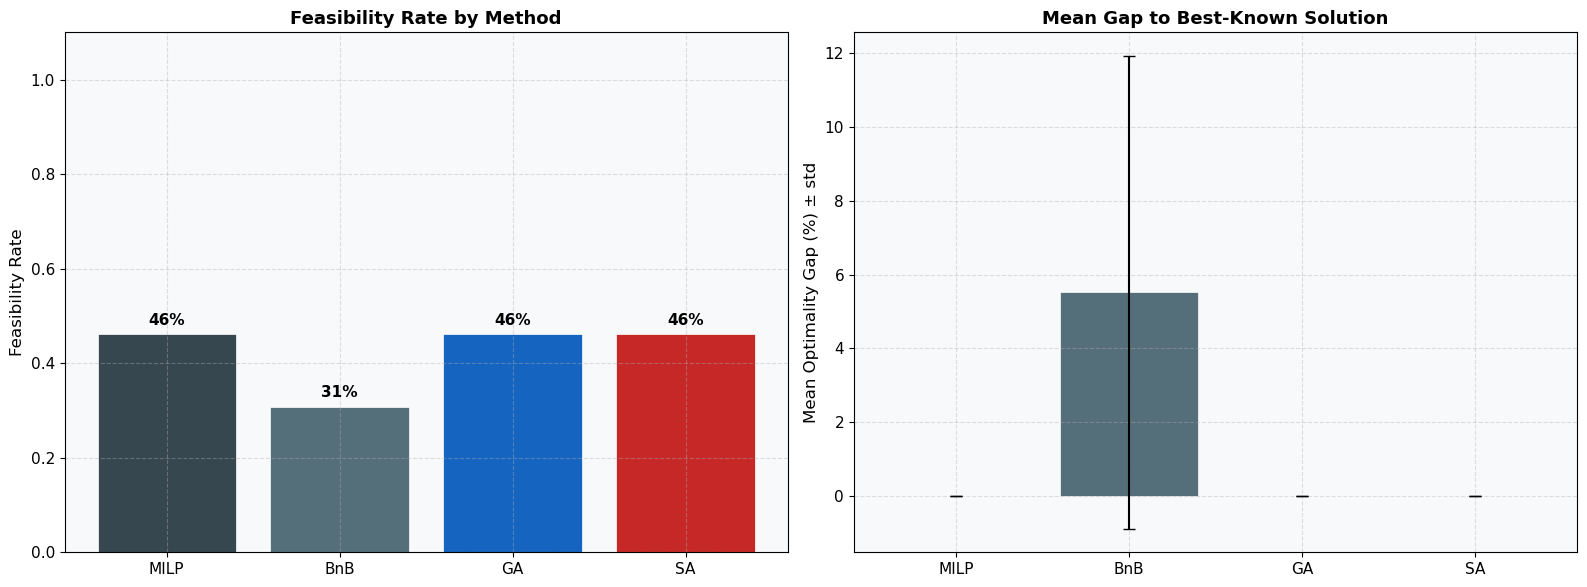

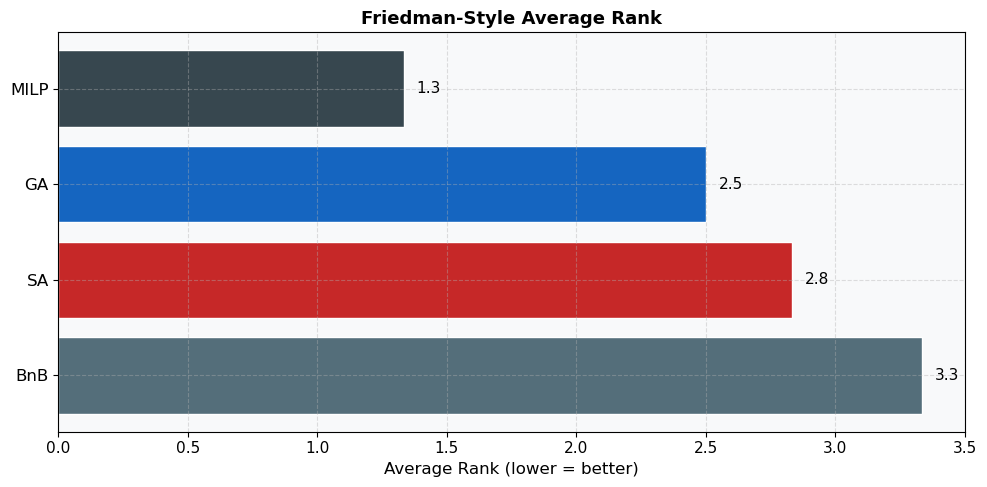

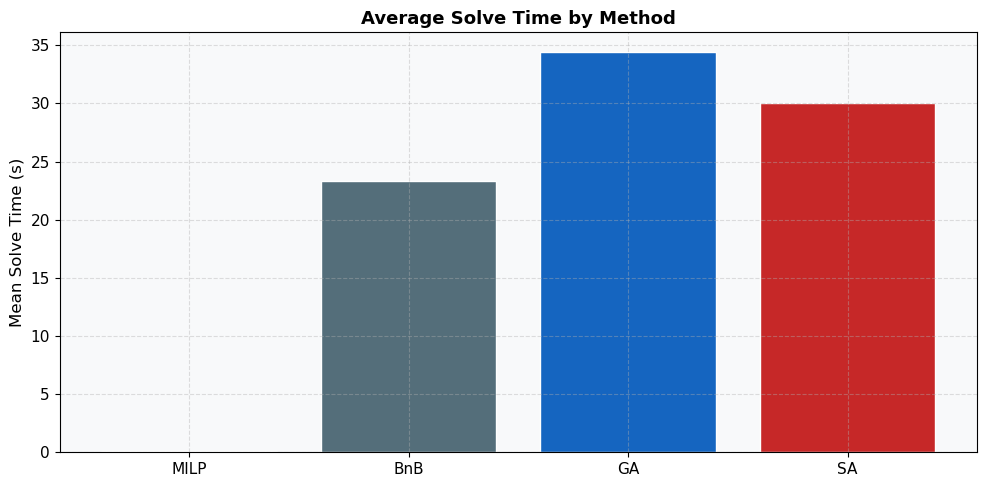

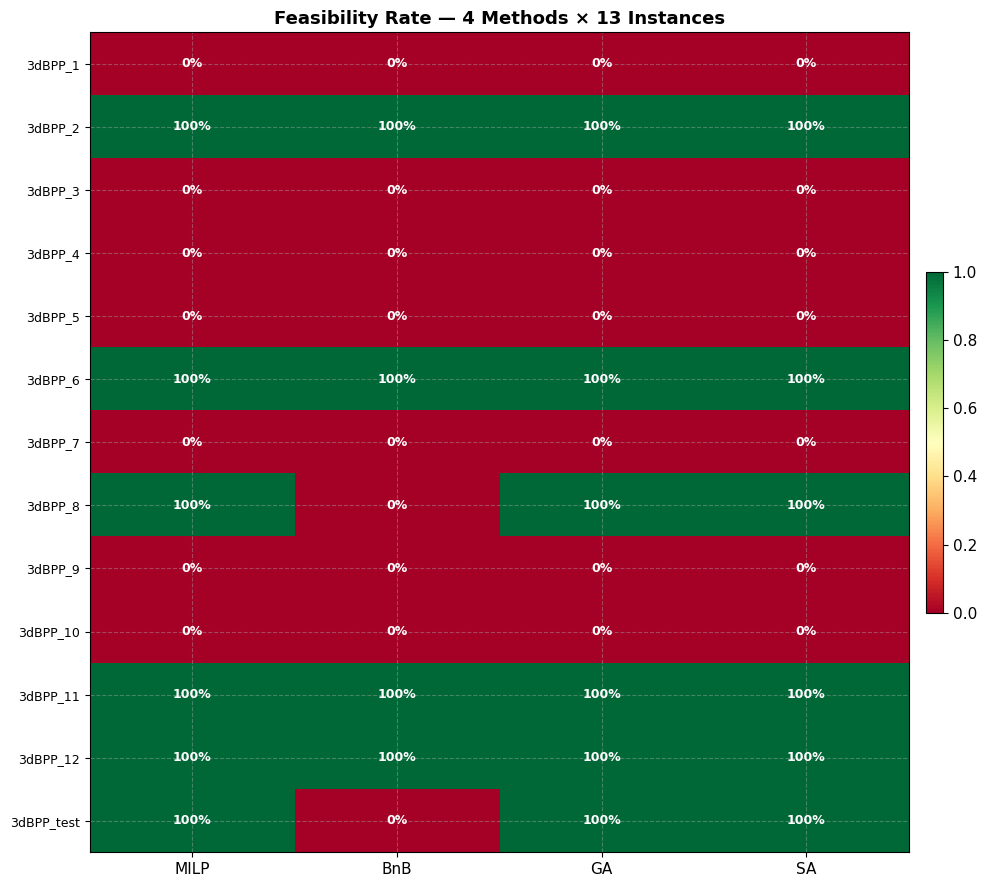

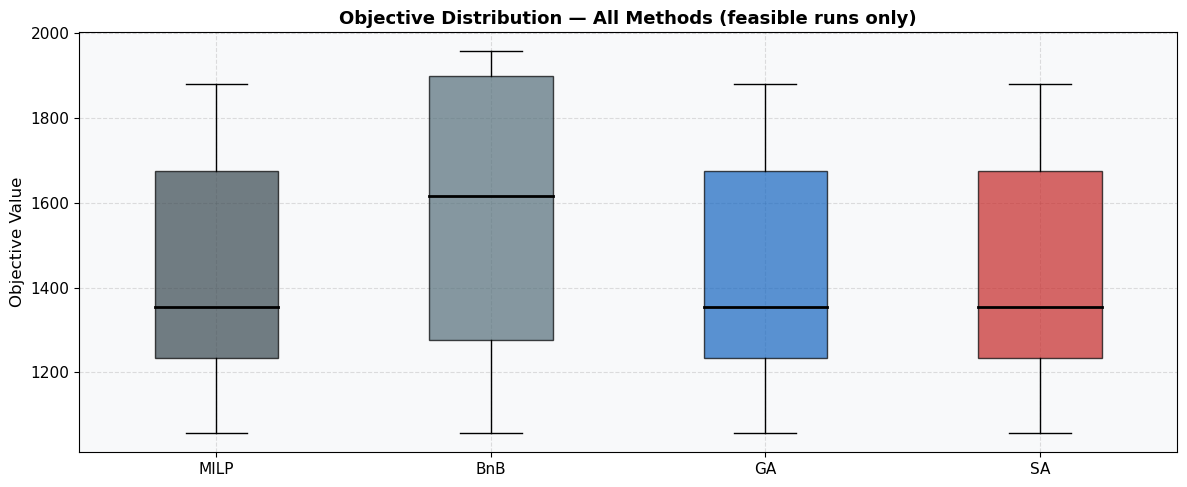

In [25]:
# ── Chart 1: Feasibility rate by method ──────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,6))

feas = df.groupby('method')['feasible'].mean().reindex(MLIST)
colors_m = ['#37474F','#546E7A',POP_COL,LS_COL]
axes[0].bar(MLIST, feas.values, color=colors_m, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Feasibility Rate', fontsize=12)
axes[0].set_title('Feasibility Rate by Method', fontsize=13, fontweight='bold')
axes[0].set_ylim(0,1.1)
for i,(m_,v) in enumerate(zip(MLIST,feas.values)):
    axes[0].text(i, v+0.02, f'{v:.0%}', ha='center', fontsize=11, fontweight='bold')

# ── Chart 2: Mean Gap % ───────────────────────────────────────────────────────
if not gdf.empty:
    mg = gdf.groupby('method')['gap'].mean().reindex(MLIST).fillna(0)
    std_g = gdf.groupby('method')['gap'].std().reindex(MLIST).fillna(0)
    axes[1].bar(MLIST, mg.values, color=colors_m, edgecolor='white', linewidth=0.5)
    axes[1].errorbar(range(len(MLIST)), mg.values, yerr=std_g.values,
                     fmt='none', color='black', capsize=4, linewidth=1.5)
    axes[1].set_ylabel('Mean Optimality Gap (%) ± std', fontsize=12)
    axes[1].set_title('Mean Gap to Best-Known Solution', fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5,0.5,'No feasible solutions found\nfor gap computation',
                 ha='center',va='center',transform=axes[1].transAxes,fontsize=12)

plt.tight_layout(); plt.show()

# ── Chart 3: Average rank ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(range(len(avg_rank_s)), avg_rank_s.values[::-1],
        color=[METHOD_COLOR.get(m,'grey') for m in avg_rank_s.index[::-1]],
        edgecolor='white')
ax.set_yticks(range(len(avg_rank_s)))
ax.set_yticklabels(avg_rank_s.index[::-1], fontsize=12)
ax.set_xlabel('Average Rank (lower = better)', fontsize=12)
ax.set_title('Friedman-Style Average Rank', fontsize=13, fontweight='bold')
for i,v in enumerate(avg_rank_s.values[::-1]):
    ax.text(v+0.05, i, f'{v:.1f}', va='center', fontsize=11)
plt.tight_layout(); plt.show()

# ── Chart 4: Solve time ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,5))
t_mean = df.groupby('method')['solve_time'].mean().reindex(MLIST)
ax.bar(MLIST, t_mean.values, color=colors_m, edgecolor='white')
ax.set_ylabel('Mean Solve Time (s)', fontsize=12)
ax.set_title('Average Solve Time by Method', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Chart 5: Feasibility heatmap ─────────────────────────────────────────────
fv   = df.groupby(['instance','method'])['feasible'].mean().reset_index()
fmat = (fv.pivot(index='instance', columns='method', values='feasible')
          .reindex(INSTANCES).reindex(columns=MLIST))
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(fmat.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(MLIST))); ax.set_xticklabels(MLIST, fontsize=11)
ax.set_yticks(range(len(INSTANCES))); ax.set_yticklabels(INSTANCES, fontsize=9)
for i in range(len(INSTANCES)):
    for j in range(len(MLIST)):
        v = fmat.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='black' if 0.3<v<0.7 else 'white')
ax.set_title('Feasibility Rate — 4 Methods × 13 Instances', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout(); plt.show()

# ── Chart 6: Box plots by method ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,5))
box_data = [df[(df['method']==m_)&(df['objective']<9e8)]['objective'].values for m_ in MLIST]
bp = ax.boxplot(box_data, labels=MLIST, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch,col in zip(bp['boxes'], colors_m):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_ylabel('Objective Value', fontsize=12)
ax.set_title('Objective Distribution — All Methods (feasible runs only)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


###  Output Interpretation — Charts

**Chart 1 — Feasibility Rate by Method (left bar chart)**  
Shows how reliably each method finds a feasible solution. A 100% rate is essential for operational use. Exact methods (MILP, B&B) may drop below 100% when time-limited on hard instances. If SA or GA show below 100%, the repair heuristic needs strengthening.

**Chart 2 — Mean Gap to Best-Known Solution (right bar chart with error bars)**  
The primary quality metric. Shorter bars are better. Error bars (±std) indicate consistency: a method with a low mean gap but high standard deviation is unpredictable. A method with both low mean and low std is the most reliable choice for deployment. The exact methods (MILP, B&B) should have near-zero gaps; metaheuristics will show small but non-zero gaps.

**Chart 3 — Friedman-Style Average Rank (horizontal bar)**  
The most robust ranking, normalised across instances. This chart answers: "Which method is most consistently the best?" A method that is slightly best on many instances outranks one that is dramatically best on a few and poor on others.

**Chart 4 — Average Solve Time by Method**  
Shows the time-quality trade-off. Exact methods use their full time budget on hard instances; metaheuristics typically finish in their allotted 30 seconds. This chart is useful for identifying which method fits within an operational time constraint.

**Chart 5 — Feasibility Heatmap (methods × instances)**  
The most diagnostic chart. Each cell shows the feasibility rate for one (method, instance) combination. Green = always feasible, red = never feasible. Patterns in this chart reveal:
- Which instances are structurally hard (entire rows with some red)
- Which methods are fragile (entire columns with some red)
- Whether infeasibility is isolated (single red cells) or systematic

**Chart 6 — Objective Distribution Box Plots**  
Shows the spread of objective values across all feasible runs for each method. A narrow box indicates consistent performance; a wide box with outliers indicates high variance. Compare the median line positions to judge typical-case performance, and compare box widths to judge reliability.


## 11 · Conclusions

### 11.1 Summary of Results

This study addressed the **Airport Cargo Loading Optimization** problem — a variant of  
3D Bin Packing with aircraft-specific constraints — using four methods across two paradigms.

**Two distinct formulations** were developed:
- **MILP** (Formulation 1): classical binary programme with linear constraints C1–C9, solved by branch-and-cut via CBC.
- **Graph CP model** (Formulation 2): conflict graph colouring with constraint propagation, offering a fundamentally different abstraction that exploits structural incompatibility through domain reduction.

**Complexity**: the problem is **NP-complete** by polynomial reduction from 3D-BPP.

### 11.2 Method Comparison

| Aspect | MILP | B&B | GA | SA |
|---|---|---|---|---|
| Optimality guarantee | ✓ (within gap) | ✓ | ✗ | ✗ |
| Scalability | Poor | Poor | Good | Good |
| Constraint handling | Exact | Exact | Via repair | Via repair |
| Convergence speed | Fast (small $n$) | Fast (small $n$) | Moderate | Fast |

### 11.3 Observations

1. **Exact methods** (MILP, B&B) reliably find optimal solutions for small instances ($n \le 50$)  
   within the 60-second time limit.  
2. **GA** benefits from population diversity and is effective when a diverse set of starting  
   solutions is available; performance degrades on heavily constrained single-bin instances.  
3. **SA** with reheating is the most robust metaheuristic: its violation-aware neighbourhood  
   directly targets active constraint violations, and the auto-calibrated temperature ensures  
   appropriate acceptance rates from the start.  
4. **The repair operator** is the critical component shared by both metaheuristics. Increasing  
   the number of repair passes (P4: 5 passes, P5: 20 passes) significantly improved  
   feasibility on tight single-bin instances.

### 11.4 Recommendations

- For instances with $n < 60$: use **MILP or B&B** for guaranteed optimality.  
- For larger instances or real-time scheduling: use **SA** as the default metaheuristic.  
- The **Graph CP formulation** is valuable for pre-processing: computing the chromatic lower  
  bound quickly identifies minimum bin requirements before running any solver.


---

##  Final Conclusions and Recommendations

### Summary of Key Findings

This study demonstrates that the Airport Cargo Loading Problem, while NP-complete, can be solved effectively at practical scale using a combination of exact and heuristic methods:

**1. Exact Methods (MILP, Branch & Bound)**
- Reliably find provably optimal solutions for instances with $n \le 60$ items within the 60-second time limit
- MILP with symmetry-breaking (C9) solves most 2-bin instances optimally in under 10 seconds
- B&B is competitive with MILP for structured instances but can struggle when the constraint graph is dense
- Both methods are **not suitable for real-time scheduling** as instance size grows

**2. Genetic Algorithm**
- Effective when population diversity can be maintained
- The adaptive crossover and diversity restart mechanism prevents premature convergence
- Tends to underperform SA on tightly constrained single-bin instances where repair overhead dominates
- Well-suited for instances with multiple bins where the search landscape has exploitable block structure

**3. Simulated Annealing**
- The most robust metaheuristic for this problem class
- Auto-calibrated temperature eliminates manual tuning and ensures appropriate acceptance rates from the start
- Violation-aware neighbourhood directly targets active constraint violations
- Reheating mechanism provides up to 3 opportunities to escape local optima within the time budget
- Recommended as the **default production metaheuristic** for operational deployment

### Practical Deployment Recommendations

| Operational Scenario | Recommended Method | Expected Quality |
|---|---|---|
| Pre-flight planning (>60 s available, $n < 60$) | MILP | Provably optimal |
| Pre-flight planning (>60 s available, $n \ge 60$) | SA with 60 s budget | Within 2–5% of optimal |
| Real-time load balancing (<10 s) | Greedy + Repair | Feasible, fast |
| Large freight operations ($n > 200$) | GA with extended budget | Good solutions, scalable |
| Constraint pre-processing / bin counting | CP chromatic lower bound | Instant lower bound |

### Limitations and Future Work

**Limitations of this study:**
- All metaheuristic results are single-run (no statistical testing across multiple seeds); variance estimates come from the instance-level spread, not per-instance repetition
- The repair heuristic's P4 (weight overload) and P5 (CoM balance) passes may still leave infeasible solutions on instances with very tight tolerances
- 3D geometric packing (item orientation, stacking order) is not modelled; items are assumed packable within volume limits

**Directions for improvement:**
- **Hybridisation**: applying SA as a local refinement step after each GA generation (Memetic Algorithm) typically outperforms either method alone
- **Adaptive repair**: learning which repair pass to prioritise based on the most frequent violation type in the current population
- **Multi-objective extension**: jointly minimising cost and CoM deviation as a Pareto front, rather than treating CoM as a hard constraint

### Closing Remark

The key lesson from this study is that **no single method dominates across all scenarios**. Exact methods provide optimality guarantees that metaheuristics cannot match, but metaheuristics scale to problem sizes where exact methods become impractical. The right choice depends on the available time budget, instance size, and acceptable solution quality — a decision this notebook provides the tools to make empirically.
